In [1]:
import numpy as np
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import math
from scipy.stats import skewnorm
from scipy import special
import os
import random
import sklearn
from sklearn.metrics import DistanceMetric
dist = DistanceMetric.get_metric('euclidean')
import copy
import seaborn as sns
from scipy.stats import chi2, multivariate_normal
import time
from sklearn.neighbors import NearestNeighbors
from scipy.special import gammaln

In [3]:
primary_colors = [
    '#F44336',
    '#E91E63',  
    '#9C27B0',  
    '#673AB7',
    '#3F51B5', 
    '#2196F3',
    '#03A9F4',
    '#00BCD4',
    '#009688',
    '#4CAF50',
    '#8BC34A',
    '#CDDC39',
    '#FFEB3B',
    '#FFC107',
    '#FF9800',
    '#FF5722',
    '#795548',
    '#9E9E9E',
    '#607D8B'
]

In [4]:
def RE_analytical(d, alpha, cov):
    RE = np.log2((2*np.pi)**(d/2)* (np.linalg.det(cov))**0.5) + (1/(1-alpha))*np.log2(alpha**(-d/2))
    return RE

In [5]:
def ar(alpha,beta,gamma,n, noise):
   A=[]
   B=[]
   a=np.random.normal(0, 1)
   b=np.random.normal(0, noise)
   A.append(a)
   B.append(b)

   for i in range(1,n):

      ee=np.random.normal(0, noise)
      b=beta*b + gamma*a + ee
      B.append(b)
      e=np.random.normal(0, 1)
      a=e+alpha*a
      A.append(a)

   return(A,B)

In [71]:
rte_analy =[]
re_an_1 = []
re_an_2 = []
re_an_3 = []
re_an_4 = []

parameters=[0.2,0.5,0.8]
amin=0.03
amax=5
a_dif=0.03
alphas=np.arange(amin,amax,a_dif)

for i in parameters:

    A, B = ar(alpha=0.5,beta=0.2,gamma=i,n=100000,noise=0.5)
    
    A_s=rte.windows(A,4)
    B_t=rte.windows(B,4)

    cond=list()
    data_cond=[B]

    for i in range(0,len(data_cond)):
        cond.append(rte.windows(data_cond[i],4))

    conditionals=rte.shape_conditionals(d_cond=cond,dimensions=[1])

    dat_1, dat_2, dat_3, dat_4  = rte.prepare_data(dat_target=B_t,dat_source=A_s,dim_target=1,dim_source=1,conditionals=conditionals,dim_future=1)


    cov_1 = np.cov(dat_1.T[1],dat_1.T[0])
    cov_2 = [[np.var(dat_2)]]
    cov_4 = np.cov(dat_4.T[1],dat_4.T[0])

    cov_3 = np.zeros((3,3))

    cov_3[0][0:2]=np.cov(dat_3.T[2],dat_3.T[1])[0]
    cov_3[0][2]=np.cov(dat_3.T[2],dat_3.T[0])[0][1]

    cov_3[1][0:2]=np.cov(dat_3.T[2],dat_3.T[1])[1]
    cov_3[1][2]=np.cov(dat_3.T[1],dat_3.T[0])[0][1]

    cov_3[2][1:3]=np.cov(dat_3.T[1],dat_3.T[0])[1]
    cov_3[2][0]=np.cov(dat_3.T[0],dat_3.T[2])[0][1]

    RE_analy_1 = [RE_analytical(2,alpha,cov_1) for alpha in alphas] 

    RE_analy_2 = [RE_analytical(1,alpha,cov_2) for alpha in alphas] 

    RE_analy_3 = [RE_analytical(3,alpha,cov_3) for alpha in alphas] 

    RE_analy_4 = [RE_analytical(2,alpha,cov_4) for alpha in alphas] 

    rte_analy.append(rte.rte(RE_analy_1,RE_analy_2,RE_analy_3,RE_analy_4))
    re_an_1.append(RE_analy_1)
    re_an_2.append(RE_analy_2)
    re_an_3.append(RE_analy_3)
    re_an_4.append(RE_analy_4)

In [6]:
def ar_cube(alpha,beta,gamma,n, noise):
   A=[]
   B=[]
   a=np.random.normal(0, 1)
   b=np.random.normal(0, noise)
   A.append(a)
   B.append(b)

   for i in range(1,n):

      ee=np.random.normal(0, noise)
      b=beta*b + gamma*pow(a,3) + ee
      B.append(b)
      e=np.random.normal(0, 1)
      a=e+alpha*a
      A.append(a)

   return(A,B)

In [98]:
def ar_lin(alpha,beta,ceta,gamma,kappa,n, noise):

   A=[]
   B=[]
   C=[]
   a=np.random.normal(0, 1)
   b=np.random.normal(0, noise)
   c=np.random.normal(0, 1)

   A.append(a)
   B.append(b)
   C.append(c)


   for i in range(1,n):

      ee=np.random.normal(0, noise)
      b=beta*b + gamma*a + kappa*c + ee
      B.append(b)
      e=np.random.normal(0, 1)
      a=e+alpha*a
      A.append(a)
      eee=np.random.normal(0, 1)
      c=eee+ceta*c
      C.append(c)

   return(A,B,C)

In [107]:
def ar_lin_cube(alpha,beta,ceta,gamma,kappa,n, noise):

   A=[]
   B=[]
   C=[]
   a=np.random.normal(0, 1)
   b=np.random.normal(0, noise)
   c=np.random.normal(0, 1)

   A.append(a)
   B.append(b)
   C.append(c)


   for i in range(1,n):

      ee=np.random.normal(0, noise)
      b=beta*b + gamma*a + kappa*pow(c,3) + ee
      B.append(b)
      e=np.random.normal(0, 1)
      a=e+alpha*a
      A.append(a)
      eee=np.random.normal(0, 1)
      c=eee+ceta*c
      C.append(c)

   return(A,B,C)

In [7]:
def flatten(data):
    return np.asarray([[elem[0] for elem in row] for row in data])

def plot_quantiles(alphas, data, color, label):

    quantiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

    quantile_values = np.quantile(data, q=quantiles, axis=0)

    ax.fill_between(alphas, quantile_values[0], quantile_values[-1], color=color, alpha=0.2)# label='1–99%')
    ax.fill_between(alphas, quantile_values[1], quantile_values[-2], color=color, alpha=0.4) #label='5–95%')
    ax.fill_between(alphas, quantile_values[2], quantile_values[-3], color=color, alpha=0.6) #label='25–75%')

    if label==False:
        ax.plot(alphas, quantile_values[3], color=color)
    else:
        ax.plot(alphas, quantile_values[3], color=color,label=label)

In [8]:
amin=0.03
amax=5
a_dif=0.03
alphas=np.arange(amin,amax,a_dif)

In [66]:
def renyi_Leonenko(neigh_num,alphas,data):

    m=data.shape[1]
    V=pow(math.pi,m/2)/math.gamma(m/2+1)  

    max_k = max(neigh_num)+1

    knn = NearestNeighbors(n_neighbors=max_k, algorithm='brute', metric='euclidean')
  

    knn.fit(data)

    distances, indices = knn.kneighbors(data)

    H=list()

    for q in alphas:
        kn=list()
        for k in neigh_num:
            C=pow(np.exp( gammaln(k) - gammaln(k + 1 - q) ),1/(1-q))
            knn=distances[:, k]       
            knn=knn[np.where(knn>0)]
            norm=len(knn)
            I=np.sum(pow(pow(knn,m)*V*(norm-1)*C,1-q))/norm
            kn.append(1/(1-q)*math.log2(I))
        H.append(kn)
    
    return np.array(H)

In [14]:
def windows(vector,size):
    
    dim=len(vector)
    w=np.arange(0,dim-size,1)
    for i in range(0,size):
        li=list(np.arange(0,i,1))+list(np.arange(dim-size+i,dim,1))
        v=np.delete(vector,li)
        w=np.vstack((w,v))
    w=np.delete(w, 0, axis=0).T
    
    return w 

In [15]:
def prepare_data(conditionals,dat_target,dat_source,dim_target,dim_source,dim_future):
    
    one=np.hstack((conditionals,dat_target[:,dim_target:(dim_target+dim_future)]))
    two=conditionals
    
    three=np.hstack((dat_source[:,0:dim_source],conditionals,dat_target[:,dim_target:(dim_target+dim_future)]))
    four=np.hstack((dat_source[:,0:dim_source],conditionals))

    return one, two, three, four




def prepare_data_sh(conditionals, dat_target, dat_source, dim_target, dim_source, dim_future):

    y_sh=copy.deepcopy(dat_source[:,0:dim_source])
    y_sh=y_sh[np.random.permutation(len(y_sh))]

    three_sh=np.hstack((y_sh, conditionals, dat_target[:,dim_target:(dim_target+dim_future)]))
    four_sh=np.hstack((y_sh, conditionals))

    return three_sh, four_sh
    
    

In [16]:
def ensure_list_in_list(data):

    if isinstance(data, list) and all(isinstance(item, list) for item in data):
        return data 
    return [data] if isinstance(data, list) else [[data]]




def data_length_check(data_target, data_source, data_cond):#data_cond is a list of vectors

    data_cond=ensure_list_in_list(data_cond)

    length = len(data_target)
    if len(data_source) != length:
        return False

    for vec in data_cond:
        if len(vec) != length:
            return False
    
    return print(f"All vectors have the same length equal to: {length}")



In [17]:
def shape_conditionals(d_cond, dimensions):#d_cond is a list of windows output, dimensions is a list of respective markov parameters

    l=len(dimensions)
    dc=list()
    conditionals=list()
    
    for i in range(0,l):
        dc.append(np.array(d_cond[i][:,0:dimensions[i]]))

    conditionals=np.hstack([arr for arr in dc])
    
    return conditionals



In [67]:
def re_sep(data_target, data_source, data_cond, dimensions, par_windows, dim_target, dim_source, dim_future, neigh_num, alphas):

    data_length_check(data_target=data_target, data_source=data_source, data_cond=data_cond)
    
    cond=list()
    for i in range(0,len(data_cond)):
        cond.append(windows(data_cond[i],par_windows))

    conditionals=shape_conditionals(d_cond=cond,dimensions=dimensions)

    dat_target = windows(data_target,par_windows)
    dat_source = windows(data_source,par_windows)

    one, two, three, four = prepare_data(conditionals=conditionals,dat_target=dat_target,dat_source=dat_source,dim_target=dim_target,dim_source=dim_source,dim_future=dim_future)


    time_n = time.time()
    print(f"RE 1/6: {time.ctime(time_n)}")
    H_1=renyi_Leonenko(neigh_num=neigh_num,alphas=alphas,data=one)  
    
    time_n = time.time()
    print(f"RE 2/6: {time.ctime(time_n)}")
    H_2=renyi_Leonenko(neigh_num=neigh_num,alphas=alphas,data=two) 
    
    time_n = time.time()
    print(f"RE 3/6: {time.ctime(time_n)}")
    H_3=renyi_Leonenko(neigh_num=neigh_num,alphas=alphas,data=three) 
    
    time_n = time.time()
    print(f"RE 4/6: {time.ctime(time_n)}")
    H_4=renyi_Leonenko(neigh_num=neigh_num,alphas=alphas,data=four)


    three_sh, four_sh = prepare_data_sh(conditionals=conditionals,dat_target=dat_target,dat_source=dat_source,dim_target=dim_target,dim_source=dim_source,dim_future=dim_future)

    time_n = time.time()
    print(f"RE shuffle 5/6: {time.ctime(time_n)}")
    H_3sh = renyi_Leonenko(neigh_num=neigh_num,alphas=alphas,data=three_sh)

    time_n = time.time()
    print(f"RE shuffle 6/6: {time.ctime(time_n)}")
    H_4sh = renyi_Leonenko(neigh_num=neigh_num,alphas=alphas,data=four_sh)

    return H_1, H_2, H_3, H_4, H_3sh, H_4sh
        

# To facilitate a rapid demonstration of the method, results are computed using datasets of N= 20000 samples and over L=10 runs


# PROCESS 1

In [127]:
parameters=[0.2,0.5,0.8]
L = 10
N = 20000
neigh_num = [50]
a0 = len(parameters)*L 
a1 = len(alphas) 
a2 = len(neigh_num) 

H1_pr1_b = np.zeros((a0,a1,a2)) 
H2_pr1_b = np.zeros((a0,a1,a2)) 
H3_pr1_b = np.zeros((a0,a1,a2)) 
H4_pr1_b = np.zeros((a0,a1,a2)) 

H12_pr1_b = np.zeros((a0,a1,a2)) 
H34_pr1_b = np.zeros((a0,a1,a2)) 

H3sh_pr1_b = np.zeros((a0,a1,a2)) 
H4sh_pr1_b = np.zeros((a0,a1,a2)) 

rte_pr1_b = np.zeros((a0,a1,a2)) 
erte_pr1_b = np.zeros((a0,a1,a2)) 

ll = 0

for i in parameters:

    for l in range(0,L):

        A, B = ar(alpha=0.5,beta=0.2,gamma=i,n=N,noise=0.5)
    
        H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                               data_source=A,
                                               data_cond=[B],
                                               dimensions=[1],
                                               par_windows=3,
                                               dim_target=1,
                                               dim_source=1,
                                               dim_future=1,
                                               neigh_num=neigh_num,
                                               alphas=alphas)
   

        H1_pr1_b[ll, :, :] = H1
        H2_pr1_b[ll, :, :] = H2
        H3_pr1_b[ll, :, :] = H3
        H4_pr1_b[ll, :, :] = H4


        H12_pr1_b[ll, :, :] = H1 - H2
        H34_pr1_b[ll, :, :] = H3 - H4


        H3sh_pr1_b[ll, :, :] = H3sh
        H4sh_pr1_b[ll, :, :] = H4sh

        rte_pr1_b[ll, :, :] = (H1 - H2) - (H3 - H4)
        erte_pr1_b[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        

        ll=ll+1


All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:31:20 2025
RE 2/6: Mon Dec 29 14:31:21 2025
RE 3/6: Mon Dec 29 14:31:21 2025
RE 4/6: Mon Dec 29 14:31:21 2025
RE shuffle 5/6: Mon Dec 29 14:31:22 2025
RE shuffle 6/6: Mon Dec 29 14:31:22 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:31:22 2025
RE 2/6: Mon Dec 29 14:31:23 2025
RE 3/6: Mon Dec 29 14:31:23 2025
RE 4/6: Mon Dec 29 14:31:23 2025
RE shuffle 5/6: Mon Dec 29 14:31:24 2025
RE shuffle 6/6: Mon Dec 29 14:31:24 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:31:24 2025
RE 2/6: Mon Dec 29 14:31:25 2025
RE 3/6: Mon Dec 29 14:31:25 2025
RE 4/6: Mon Dec 29 14:31:25 2025
RE shuffle 5/6: Mon Dec 29 14:31:25 2025
RE shuffle 6/6: Mon Dec 29 14:31:26 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:31:26 2025
RE 2/6: Mon Dec 29 14:31:26 2025
RE 3/6: Mon Dec 29 14:31:27 2025
RE 4/6: Mon Dec 29 14:31:27 2025
RE shuffle 5/6: Mon Dec 29 14:

In [128]:
parameters=[0.2,0.5,0.8]
L = 10
N = 20000
neigh_num = [3]
a0 = len(parameters)*L 
a1 = len(alphas) 
a2 = len(neigh_num) 

H1_pr1_s = np.zeros((a0,a1,a2)) 
H2_pr1_s = np.zeros((a0,a1,a2)) 
H3_pr1_s = np.zeros((a0,a1,a2)) 
H4_pr1_s = np.zeros((a0,a1,a2)) 

H12_pr1_s = np.zeros((a0,a1,a2)) 
H34_pr1_s = np.zeros((a0,a1,a2)) 

H3sh_pr1_s = np.zeros((a0,a1,a2)) 
H4sh_pr1_s = np.zeros((a0,a1,a2)) 

rte_pr1_s = np.zeros((a0,a1,a2)) 
erte_pr1_s = np.zeros((a0,a1,a2)) 




ll = 0

for i in parameters:

    for l in range(0,L):

        A, B = ar(alpha=0.5,beta=0.2,gamma=i,n=N,noise=0.5)
    
        H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                               data_source=A,
                                               data_cond=[B],
                                               dimensions=[1],
                                               par_windows=3,
                                               dim_target=1,
                                               dim_source=1,
                                               dim_future=1,
                                               neigh_num=neigh_num,
                                               alphas=alphas)
   

        H1_pr1_s[ll, :, :] = H1
        H2_pr1_s[ll, :, :] = H2
        H3_pr1_s[ll, :, :] = H3
        H4_pr1_s[ll, :, :] = H4


        H12_pr1_s[ll, :, :] = H1 - H2
        H34_pr1_s[ll, :, :] = H3 - H4


        H3sh_pr1_s[ll, :, :] = H3sh
        H4sh_pr1_s[ll, :, :] = H4sh

        rte_pr1_s[ll, :, :] = (H1 - H2) - (H3 - H4)
        erte_pr1_s[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        

        ll=ll+1


All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:32:15 2025
RE 2/6: Mon Dec 29 14:32:15 2025
RE 3/6: Mon Dec 29 14:32:16 2025
RE 4/6: Mon Dec 29 14:32:16 2025
RE shuffle 5/6: Mon Dec 29 14:32:16 2025
RE shuffle 6/6: Mon Dec 29 14:32:16 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:32:17 2025
RE 2/6: Mon Dec 29 14:32:17 2025
RE 3/6: Mon Dec 29 14:32:17 2025
RE 4/6: Mon Dec 29 14:32:18 2025
RE shuffle 5/6: Mon Dec 29 14:32:18 2025
RE shuffle 6/6: Mon Dec 29 14:32:18 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:32:19 2025
RE 2/6: Mon Dec 29 14:32:19 2025
RE 3/6: Mon Dec 29 14:32:19 2025
RE 4/6: Mon Dec 29 14:32:19 2025
RE shuffle 5/6: Mon Dec 29 14:32:20 2025
RE shuffle 6/6: Mon Dec 29 14:32:20 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:32:20 2025
RE 2/6: Mon Dec 29 14:32:21 2025
RE 3/6: Mon Dec 29 14:32:21 2025
RE 4/6: Mon Dec 29 14:32:21 2025
RE shuffle 5/6: Mon Dec 29 14:

Text(0, 0.5, 'ERTE $A \\rightarrow B^{I}$')

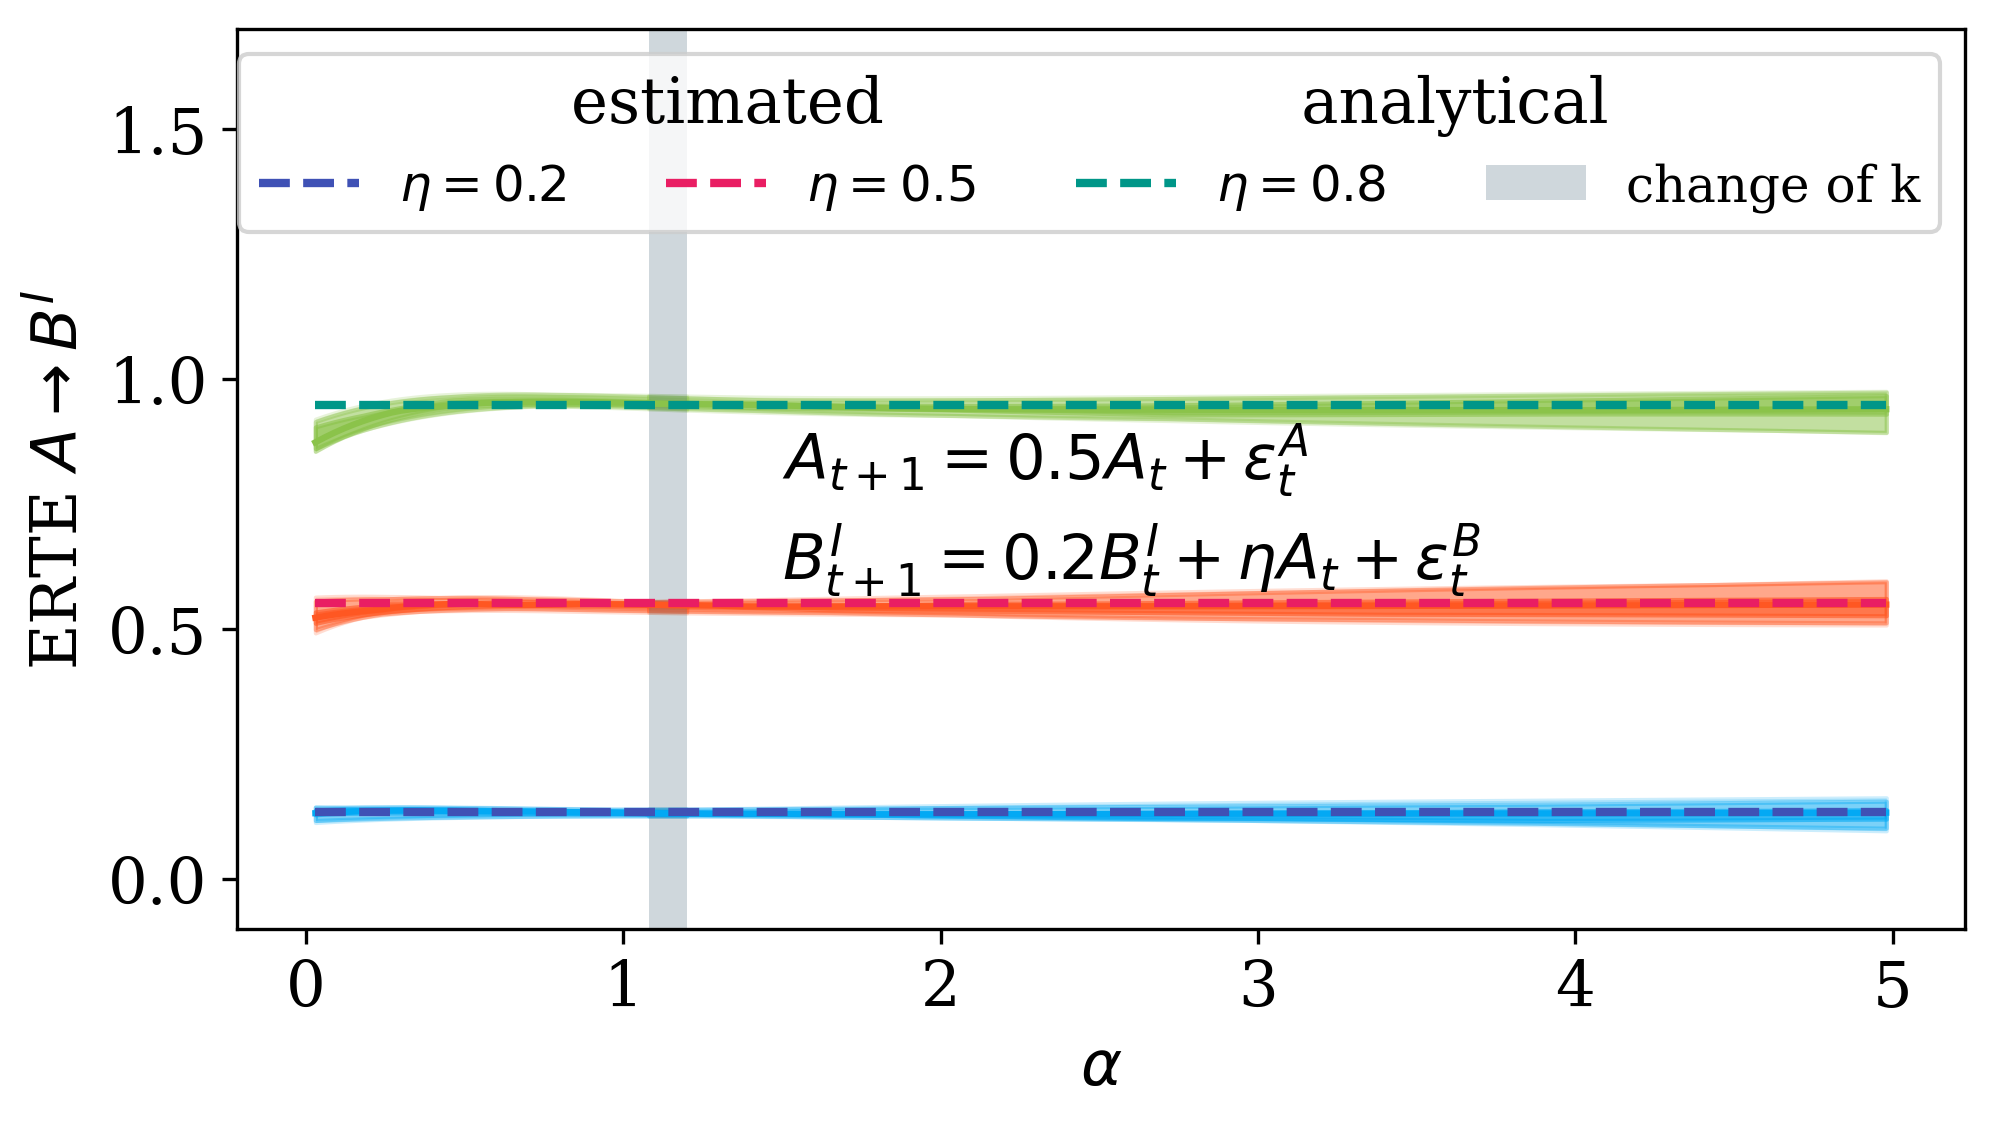

In [131]:

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif', 
    'font.size': 15
})


fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

r=40
l=35

plot_quantiles(alphas[l:],data=erte_pr1_b[:L,l:,0],color=primary_colors[6],label=False)

plot_quantiles(alphas[l:],data=erte_pr1_b[L:2*L,l:,0],color=primary_colors[15],label=False)

plot_quantiles(alphas[l:],data=erte_pr1_b[2*L:3*L,l:,0],color=primary_colors[10],label=False)


plot_quantiles(alphas[:r],data=erte_pr1_b[:L,:r,0],color=primary_colors[6],label=False)

plot_quantiles(alphas[:r],data=erte_pr1_b[L:2*L,:r,0],color=primary_colors[15],label=False)

plot_quantiles(alphas[:r],data=erte_pr1_b[2*L:3*L,:r,0],color=primary_colors[10],label=False)



ax.plot(alphas,rte_analy[0], linestyle='dashed', linewidth=2, c=primary_colors[4], label=r'$\eta=0.2$')
ax.plot(alphas,rte_analy[1], linestyle='dashed', linewidth=2, c=primary_colors[1], label=r'$\eta=0.5$')
ax.plot(alphas,rte_analy[2], linestyle='dashed', linewidth=2, c=primary_colors[8], label=r'$\eta=0.8$')

ax.fill_between(alphas[l:r], [-10,-10,-10,-10,-10],[20,20,20,20,20], color=primary_colors[18], alpha=0.3, label=r'change of k', edgecolor='none')



ax.set_ylim(-0.1,1.7)


ax.text(1.5, 0.8, r'$A_{t+1}=0.5A_{t}+ \epsilon^A_t$',  color='k')

ax.text(1.5, 0.6, r'$B^{I}_{t+1}=0.2B^{I}_{t}+\eta A_{t}+ \epsilon^B_t$',  color='k')

leg=plt.legend(loc='best', ncol=4, fontsize=12, title=r'estimated                     analytical')

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'ERTE $A \rightarrow B^{I}$')




Text(0, 0.5, 'RTE $A \\rightarrow B^{I}$')

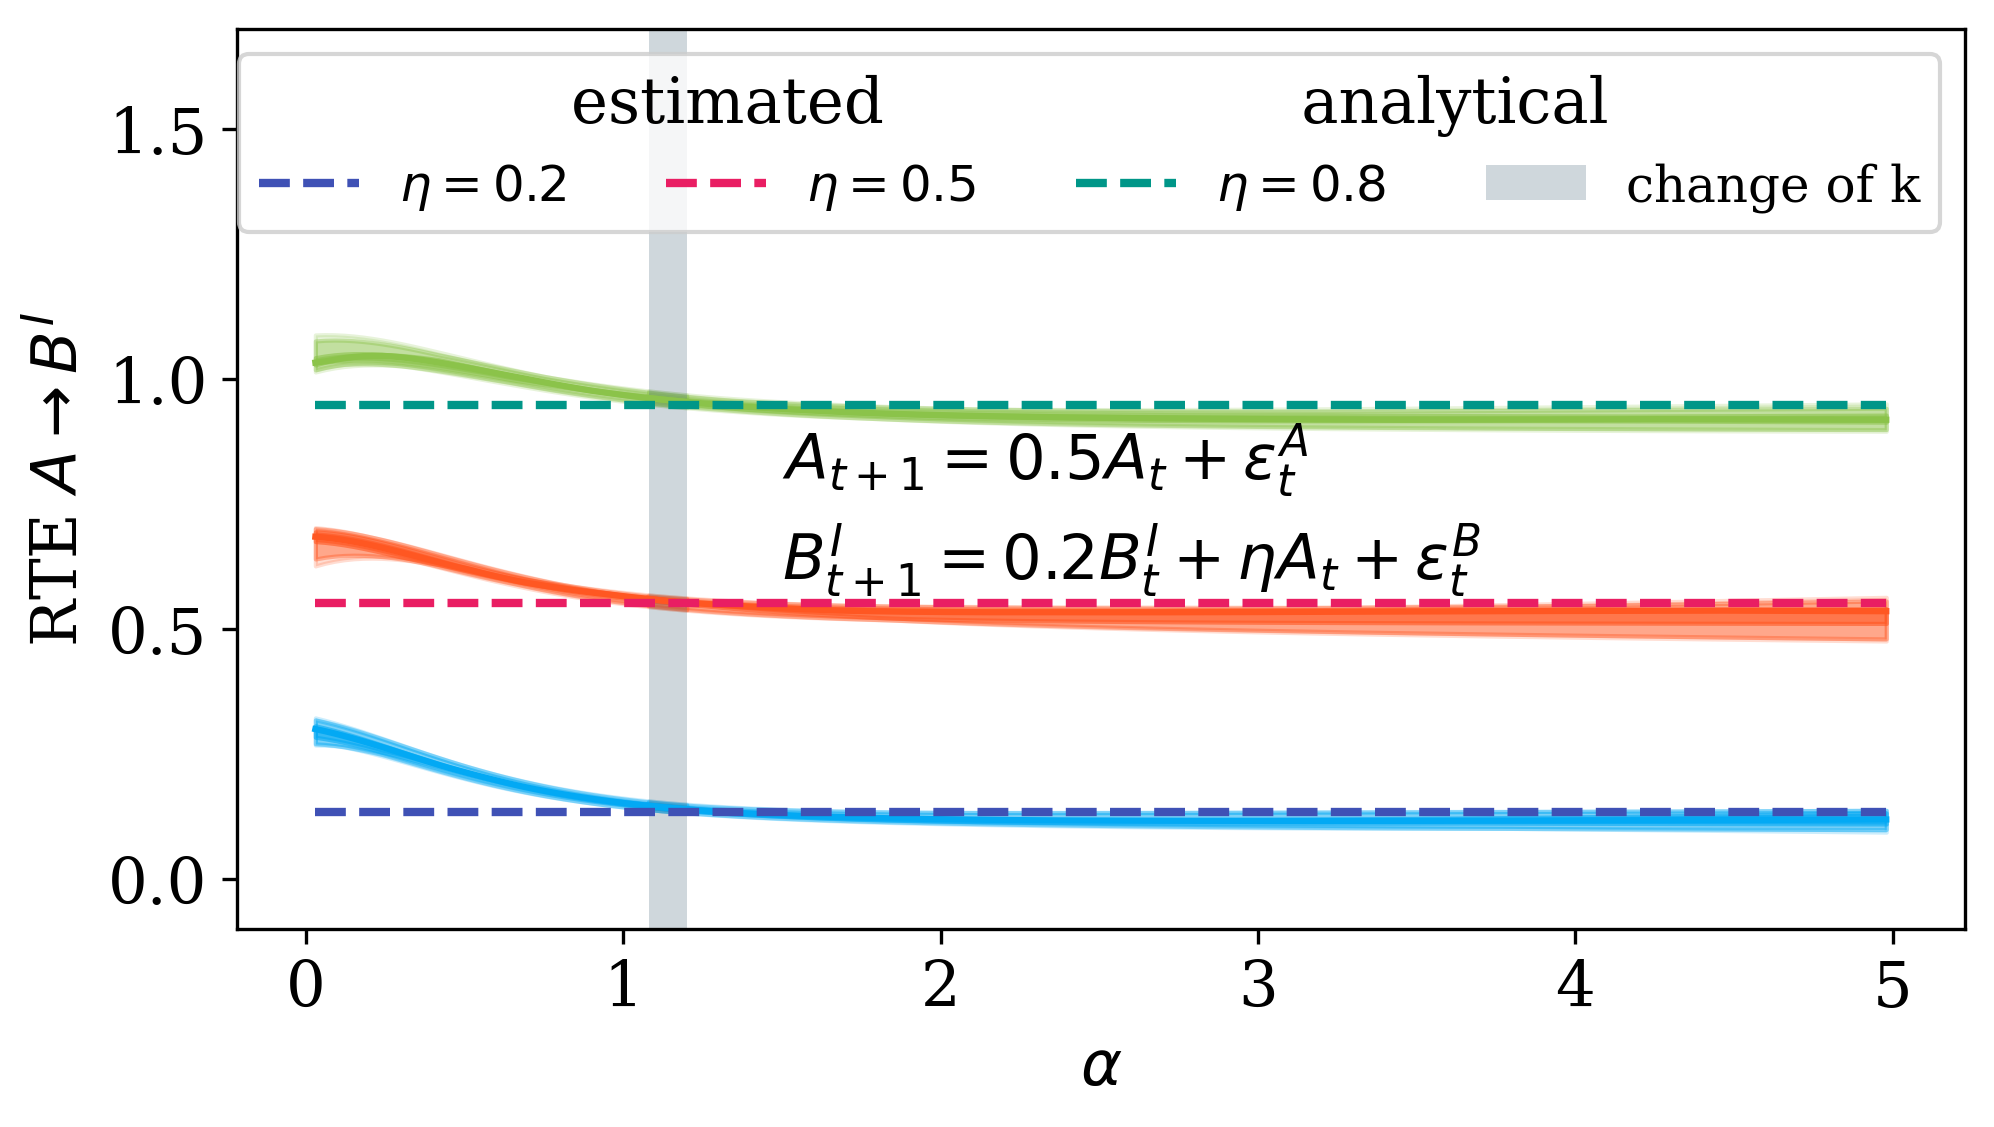

In [132]:

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',  
    'font.size': 15
})


fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

r=40
l=35


plot_quantiles(alphas[l:],data=rte_pr1_b[:L,l:,0],color=primary_colors[6],label=False)

plot_quantiles(alphas[l:],data=rte_pr1_b[L:2*L,l:,0],color=primary_colors[15],label=False)

plot_quantiles(alphas[l:],data=rte_pr1_b[2*L:3*L,l:,0],color=primary_colors[10],label=False)


plot_quantiles(alphas[:r],data=rte_pr1_b[:L,:r,0],color=primary_colors[6],label=False)

plot_quantiles(alphas[:r],data=rte_pr1_b[L:2*L,:r,0],color=primary_colors[15],label=False)

plot_quantiles(alphas[:r],data=rte_pr1_b[2*L:3*L,:r,0],color=primary_colors[10],label=False)


ax.plot(alphas,rte_analy[0], linestyle='dashed', linewidth=2, c=primary_colors[4], label=r'$\eta=0.2$')
ax.plot(alphas,rte_analy[1], linestyle='dashed', linewidth=2, c=primary_colors[1], label=r'$\eta=0.5$')
ax.plot(alphas,rte_analy[2], linestyle='dashed', linewidth=2, c=primary_colors[8], label=r'$\eta=0.8$')

ax.fill_between(alphas[l:r], [-10,-10,-10,-10,-10],[20,20,20,20,20], color=primary_colors[18], alpha=0.3, label=r'change of k', edgecolor='none')



ax.set_ylim(-0.1,1.7)


ax.text(1.5, 0.8, r'$A_{t+1}=0.5A_{t}+ \epsilon^A_t$',  color='k')

ax.text(1.5, 0.6, r'$B^{I}_{t+1}=0.2B^{I}_{t}+\eta A_{t}+ \epsilon^B_t$',  color='k')

leg=plt.legend(loc='best', ncol=4, fontsize=12, title=r'estimated                     analytical')

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'RTE $A \rightarrow B^{I}$')




Text(0, 0.5, 'RE')

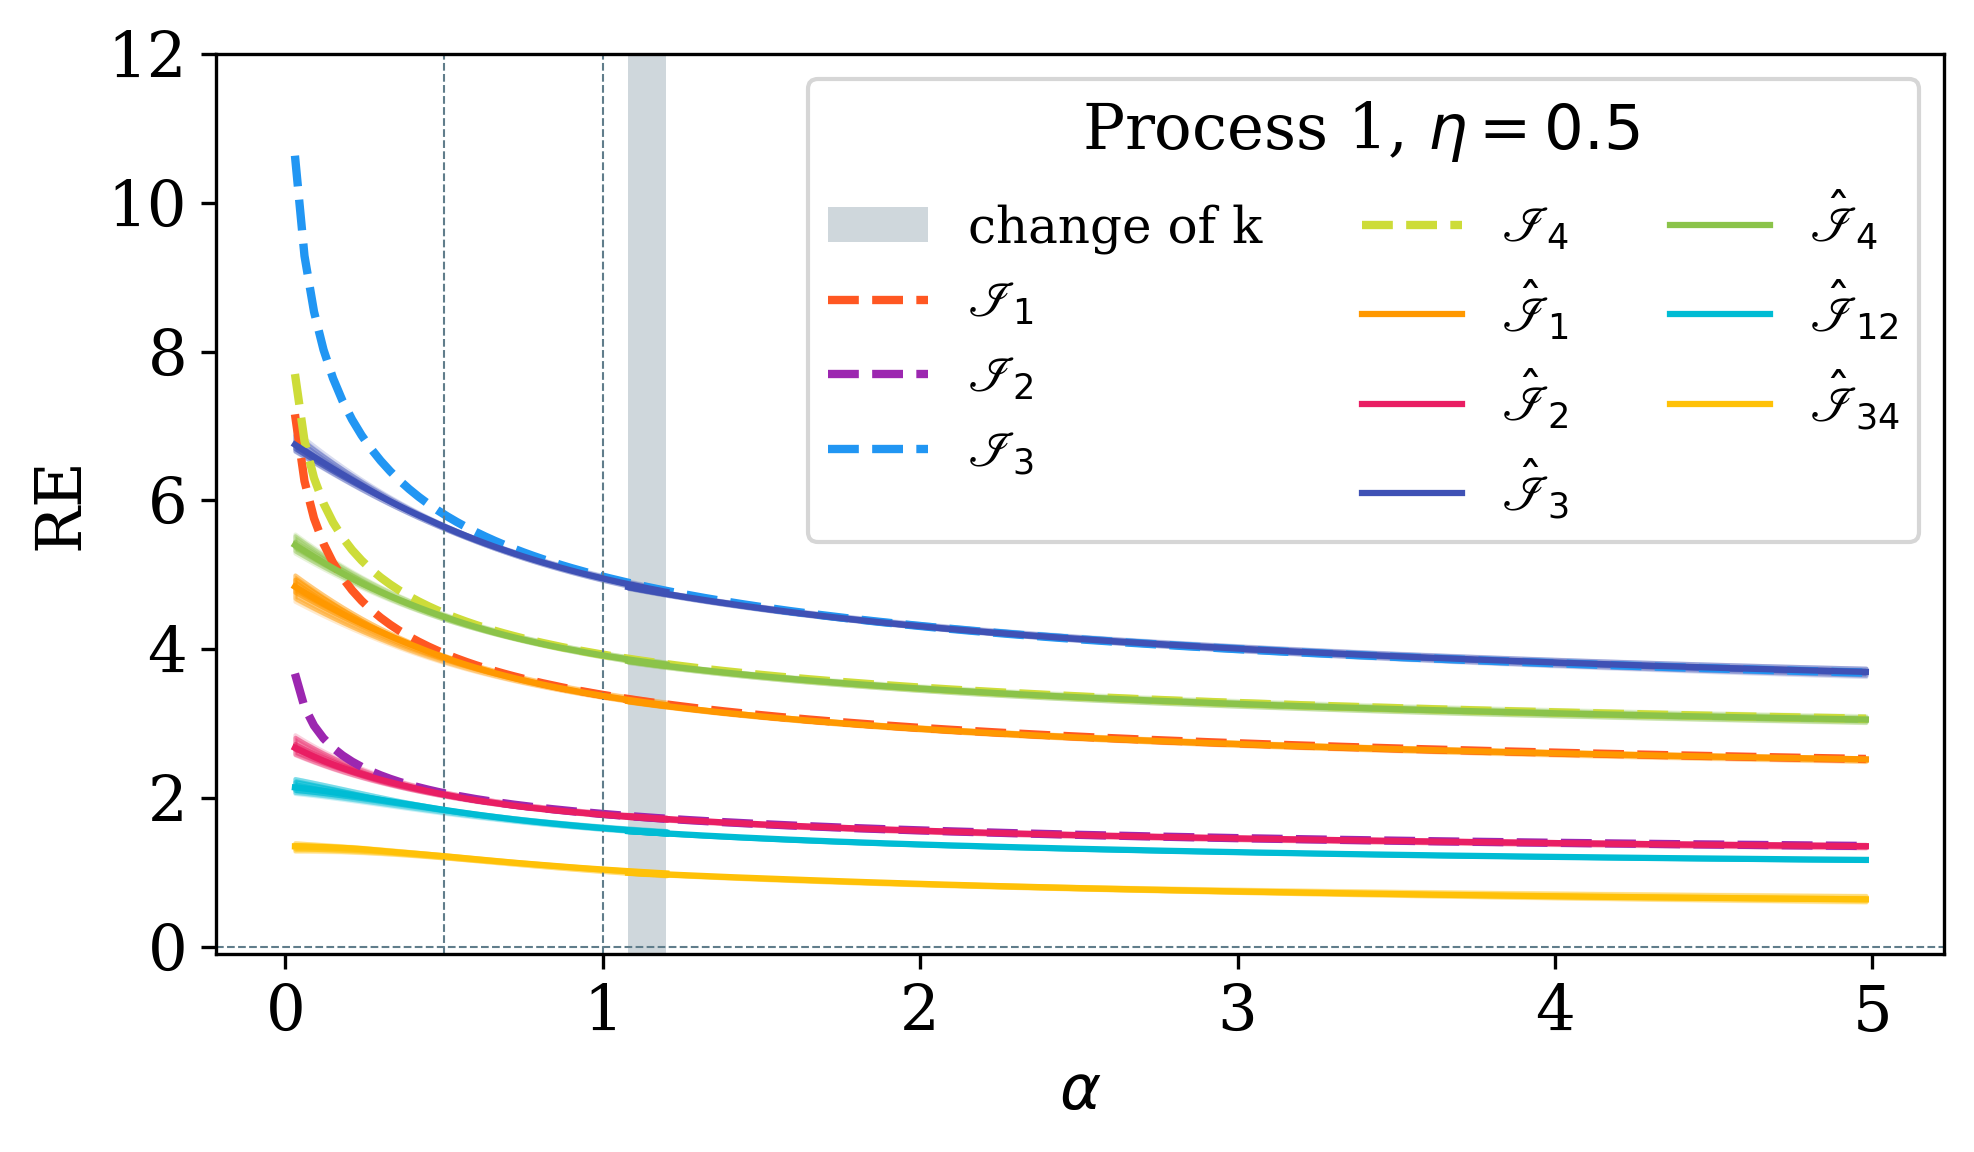

In [133]:

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif', 
    'font.size': 15
})


fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

r=40
l=35

ax.fill_between(alphas[l:r], [-10,-10,-10,-10,-10],[20,20,20,20,20], color=primary_colors[18], alpha=0.3, label=r'change of k', edgecolor='none')

ax.plot(alphas, re_an_1[1], c=primary_colors[15], linestyle='dashed', linewidth=2,label=r"$\mathscr{I}_1 $")
ax.plot(alphas, re_an_2[1], c=primary_colors[2], linestyle='dashed', linewidth=2,label=r"$\mathscr{I}_2 $")
ax.plot(alphas, re_an_3[1], c=primary_colors[5], linestyle='dashed', linewidth=2,label=r"$\mathscr{I}_3 $")
ax.plot(alphas, re_an_4[1], c=primary_colors[11], linestyle='dashed', linewidth=2,label=r"$\mathscr{I}_4 $")


plt.axvline(x=0.5, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axvline(x=1, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axhline(y=0, color=primary_colors[18], linestyle='--', linewidth=0.5)


plot_quantiles(alphas[:r],data=H1_pr1_s[L:2*L,:r,0],color=primary_colors[14],label=r'$\hat{\mathscr{I}}_1$')
plot_quantiles(alphas[:r],data=H2_pr1_s[L:2*L,:r,0],color=primary_colors[1], label=r'$\hat{\mathscr{I}}_2$')
plot_quantiles(alphas[:r],data=H3_pr1_s[L:2*L,:r,0],color=primary_colors[4], label=r'$\hat{\mathscr{I}}_3$')
plot_quantiles(alphas[:r],data=H4_pr1_s[L:2*L,:r,0],color=primary_colors[10], label=r'$\hat{\mathscr{I}}_4$')


plot_quantiles(alphas[:r],data=H12_pr1_s[L:2*L,:r,0],color=primary_colors[7], label=False)
plot_quantiles(alphas[:r],data=H34_pr1_s[L:2*L,:r,0],color=primary_colors[13], label=False)



plot_quantiles(alphas[l:],data=H1_pr1_b[L:2*L,l:,0],color=primary_colors[14], label=False)
plot_quantiles(alphas[l:],data=H2_pr1_b[L:2*L,l:,0],color=primary_colors[1], label=False)
plot_quantiles(alphas[l:],data=H3_pr1_b[L:2*L,l:,0],color=primary_colors[4], label=False)
plot_quantiles(alphas[l:],data=H4_pr1_b[L:2*L,l:,0],color=primary_colors[10], label=False)


plot_quantiles(alphas[l:],data=H12_pr1_b[L:2*L,l:,0],color=primary_colors[7], label=False)
plot_quantiles(alphas[l:],data=H34_pr1_b[L:2*L,l:,0],color=primary_colors[13], label=False)


plot_quantiles(alphas[l:r],data=H12_pr1_b[L:2*L,l:r,0],color=primary_colors[7], label=r'$\hat{\mathscr{I}}_{12}$')
plot_quantiles(alphas[l:r],data=H34_pr1_b[L:2*L,l:r,0],color=primary_colors[13], label=r'$\hat{\mathscr{I}}_{34}$')


ax.set_ylim(-0.1,12)

leg=plt.legend(loc='best', ncol=3, fontsize=12, title=r'Process 1, $\eta=0.5$ ')

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'RE')



# PROCESS 2

In [122]:
parameters=[0.2,0.5,0.8]
L = 10
N = 20000
neigh_num = [50]
a0 = len(parameters)*L 
a1 = len(alphas) 
a2 = len(neigh_num) 

H1_pr2_b = np.zeros((a0,a1,a2)) 
H2_pr2_b = np.zeros((a0,a1,a2)) 
H3_pr2_b = np.zeros((a0,a1,a2)) 
H4_pr2_b = np.zeros((a0,a1,a2)) 

H12_pr2_b = np.zeros((a0,a1,a2)) 
H34_pr2_b = np.zeros((a0,a1,a2)) 

H3sh_pr2_b = np.zeros((a0,a1,a2)) 
H4sh_pr2_b = np.zeros((a0,a1,a2)) 

rte_pr2_b = np.zeros((a0,a1,a2)) 
erte_pr2_b = np.zeros((a0,a1,a2)) 


ll = 0

for i in parameters:

    for l in range(0,L):

        A, B = ar_cube(alpha=0.5, beta=0.2, gamma=i, n=N, noise=0.5)
    
        H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                               data_source=A,
                                               data_cond=[B],
                                               dimensions=[1],
                                               par_windows=3,
                                               dim_target=1,
                                               dim_source=1,
                                               dim_future=1,
                                               neigh_num=neigh_num,
                                               alphas=alphas)
   

        H1_pr2_b[ll, :, :] = H1
        H2_pr2_b[ll, :, :] = H2
        H3_pr2_b[ll, :, :] = H3
        H4_pr2_b[ll, :, :] = H4


        H12_pr2_b[ll, :, :] = H1 - H2
        H34_pr2_b[ll, :, :] = H3 - H4


        H3sh_pr2_b[ll, :, :] = H3sh
        H4sh_pr2_b[ll, :, :] = H4sh

        rte_pr2_b[ll, :, :] = (H1 - H2) - (H3 - H4)
        erte_pr2_b[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        

        ll=ll+1


All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:56:08 2025
RE 2/6: Sat Dec 27 20:56:09 2025
RE 3/6: Sat Dec 27 20:56:09 2025
RE 4/6: Sat Dec 27 20:56:09 2025
RE shuffle 5/6: Sat Dec 27 20:56:09 2025
RE shuffle 6/6: Sat Dec 27 20:56:10 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:56:10 2025
RE 2/6: Sat Dec 27 20:56:10 2025
RE 3/6: Sat Dec 27 20:56:11 2025
RE 4/6: Sat Dec 27 20:56:11 2025
RE shuffle 5/6: Sat Dec 27 20:56:11 2025
RE shuffle 6/6: Sat Dec 27 20:56:11 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:56:12 2025
RE 2/6: Sat Dec 27 20:56:12 2025
RE 3/6: Sat Dec 27 20:56:12 2025
RE 4/6: Sat Dec 27 20:56:13 2025
RE shuffle 5/6: Sat Dec 27 20:56:13 2025
RE shuffle 6/6: Sat Dec 27 20:56:13 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:56:13 2025
RE 2/6: Sat Dec 27 20:56:14 2025
RE 3/6: Sat Dec 27 20:56:14 2025
RE 4/6: Sat Dec 27 20:56:14 2025
RE shuffle 5/6: Sat Dec 27 20:

In [120]:
parameters=[0.2,0.5,0.8]
L = 10
N = 20000
neigh_num = [3]
a0 = len(parameters)*L 
a1 = len(alphas) 
a2 = len(neigh_num) 

H1_pr2_s = np.zeros((a0,a1,a2)) 
H2_pr2_s = np.zeros((a0,a1,a2)) 
H3_pr2_s = np.zeros((a0,a1,a2)) 
H4_pr2_s = np.zeros((a0,a1,a2)) 

H12_pr2_s = np.zeros((a0,a1,a2)) 
H34_pr2_s = np.zeros((a0,a1,a2)) 

H3sh_pr2_s = np.zeros((a0,a1,a2)) 
H4sh_pr2_s = np.zeros((a0,a1,a2)) 

rte_pr2_s = np.zeros((a0,a1,a2)) 
erte_pr2_s = np.zeros((a0,a1,a2)) 


ll = 0

for i in parameters:

    for l in range(0,L):

        A, B = ar_cube(alpha=0.5, beta=0.2, gamma=i, n=N, noise=0.5)
    
        H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                               data_source=A,
                                               data_cond=[B],
                                               dimensions=[1],
                                               par_windows=3,
                                               dim_target=1,
                                               dim_source=1,
                                               dim_future=1,
                                               neigh_num=neigh_num,
                                               alphas=alphas)
   

        H1_pr2_s[ll, :, :] = H1
        H2_pr2_s[ll, :, :] = H2
        H3_pr2_s[ll, :, :] = H3
        H4_pr2_s[ll, :, :] = H4


        H12_pr2_s[ll, :, :] = H1 - H2
        H34_pr2_s[ll, :, :] = H3 - H4


        H3sh_pr2_s[ll, :, :] = H3sh
        H4sh_pr2_s[ll, :, :] = H4sh

        rte_pr2_s[ll, :, :] = (H1 - H2) - (H3 - H4)
        erte_pr2_s[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        

        ll=ll+1


All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:53:03 2025
RE 2/6: Sat Dec 27 20:53:03 2025
RE 3/6: Sat Dec 27 20:53:04 2025
RE 4/6: Sat Dec 27 20:53:04 2025
RE shuffle 5/6: Sat Dec 27 20:53:04 2025
RE shuffle 6/6: Sat Dec 27 20:53:04 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:53:05 2025
RE 2/6: Sat Dec 27 20:53:05 2025
RE 3/6: Sat Dec 27 20:53:05 2025
RE 4/6: Sat Dec 27 20:53:05 2025
RE shuffle 5/6: Sat Dec 27 20:53:06 2025
RE shuffle 6/6: Sat Dec 27 20:53:06 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:53:06 2025
RE 2/6: Sat Dec 27 20:53:06 2025
RE 3/6: Sat Dec 27 20:53:07 2025
RE 4/6: Sat Dec 27 20:53:07 2025
RE shuffle 5/6: Sat Dec 27 20:53:07 2025
RE shuffle 6/6: Sat Dec 27 20:53:07 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:53:08 2025
RE 2/6: Sat Dec 27 20:53:08 2025
RE 3/6: Sat Dec 27 20:53:08 2025
RE 4/6: Sat Dec 27 20:53:08 2025
RE shuffle 5/6: Sat Dec 27 20:

Text(0, 0.5, 'ERTE $C \\rightarrow B^{II}$')

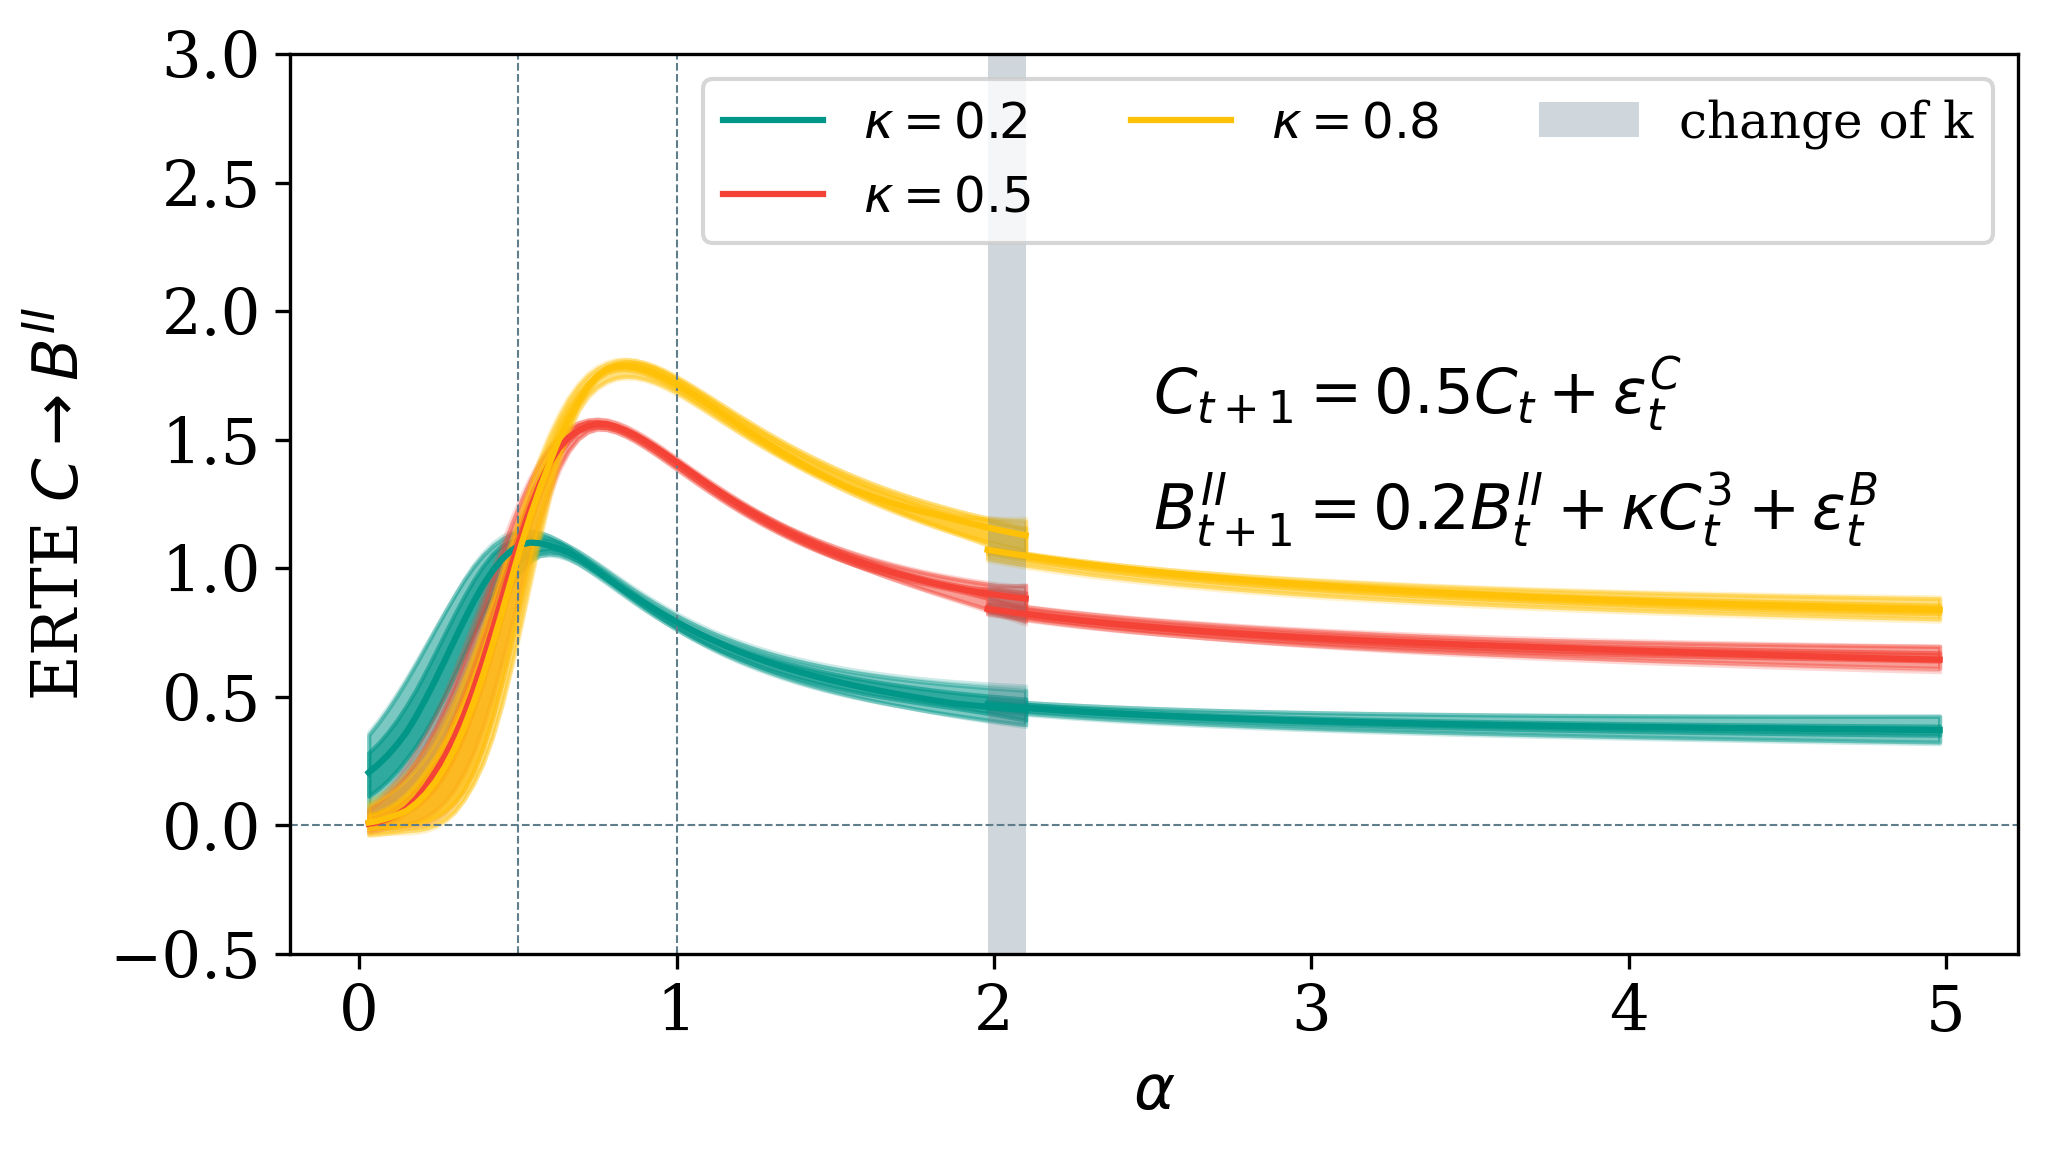

In [134]:

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',  # Or 'sans-serif', or any other LaTeX-compatible option
    'font.size': 15
})



fig = plt.figure(figsize=(7.2, 4.0), dpi=300)
left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

r=70
l=65

plt.axvline(x=0.5, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axvline(x=1, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axhline(y=0, color=primary_colors[18], linestyle='--', linewidth=0.5)




plot_quantiles(alphas[:r],data=erte_pr2_s[:L,:r,0],color=primary_colors[8], label=r'$\kappa = 0.2$')

plot_quantiles(alphas[:r],data=erte_pr2_s[L:2*L,:r,0],color=primary_colors[0], label=r'$\kappa = 0.5$')

plot_quantiles(alphas[:r],data=erte_pr2_s[2*L:3*L,:r,0],color=primary_colors[13], label=r'$\kappa = 0.8$')


plot_quantiles(alphas[l:],data=erte_pr2_b[:L,l:,0],color=primary_colors[8], label=False)

plot_quantiles(alphas[l:],data=erte_pr2_b[L:2*L,l:,0],color=primary_colors[0], label=False)

plot_quantiles(alphas[l:],data=erte_pr2_b[2*L:3*L,l:,0],color=primary_colors[13], label=False)


ax.set_ylim(-0.5,3)


#plot_quantiles(alphas[60:65],data=erte_pr2_s[:30,60:65],color=primary_colors[17], label=r'oppos.')
ax.fill_between(alphas[l:r], [-10,-10,-10,-10,-10],[20,20,20,20,20], color=primary_colors[18], alpha=0.3, label=r'change of k', edgecolor='none')

ax.text(2.5, 1.6, r'$C_{t+1}=0.5C_{t}+ \epsilon^C_t$',  color='k')

ax.text(2.5, 1.15, r'$B^{II}_{t+1}=0.2B^{II}_{t}+\kappa C^3_{t}+ \epsilon^B_t$',  color='k')

leg=plt.legend(loc='best', ncol=3, fontsize=12)

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'ERTE $C \rightarrow B^{II}$')


Text(0, 0.5, 'RTE $C \\rightarrow B^{II}$')

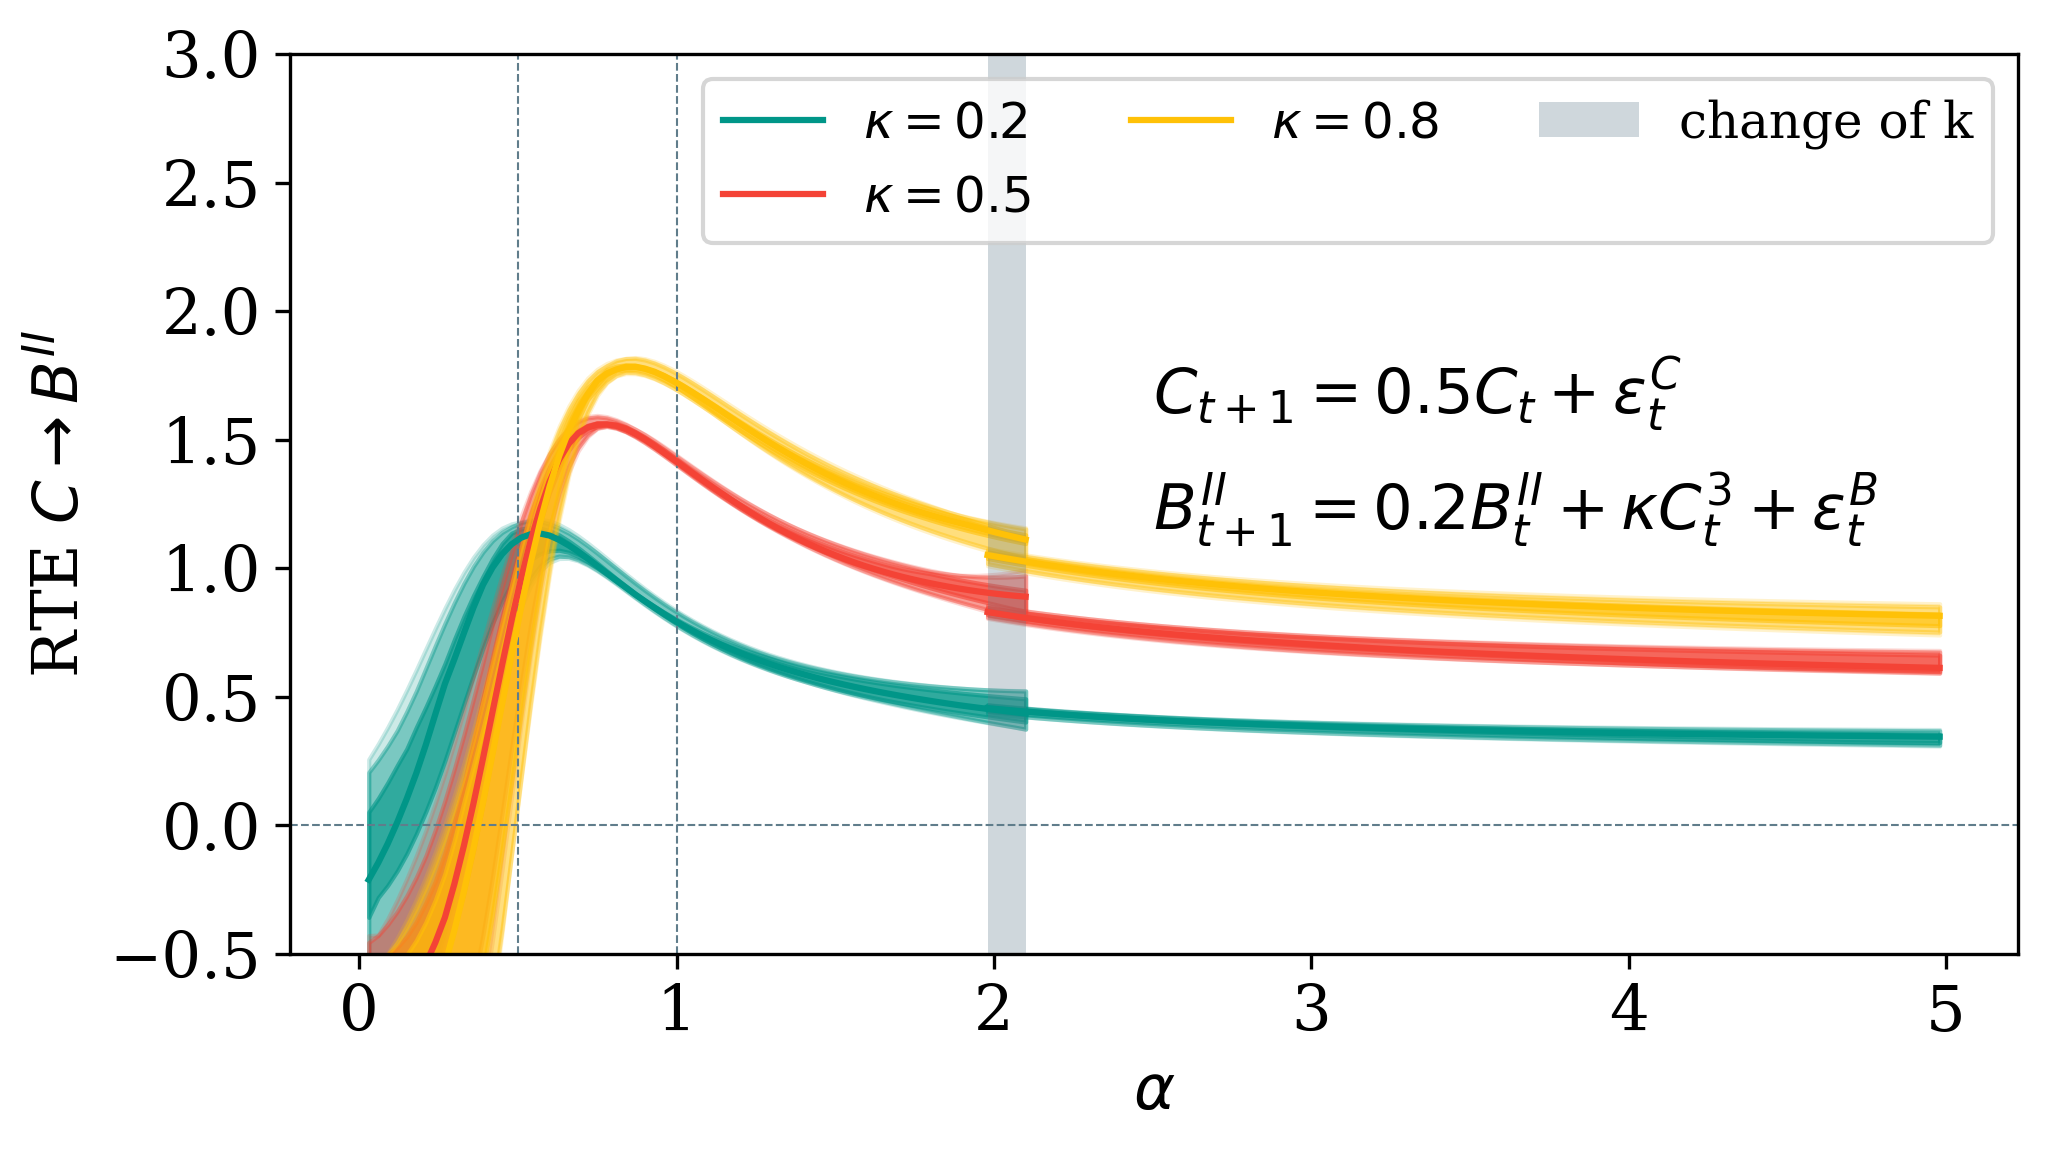

In [135]:

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',  # Or 'sans-serif', or any other LaTeX-compatible option
    'font.size': 15
})



fig = plt.figure(figsize=(7.2, 4.0), dpi=300)
left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

r=70
l=65

plt.axvline(x=0.5, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axvline(x=1, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axhline(y=0, color=primary_colors[18], linestyle='--', linewidth=0.5)




plot_quantiles(alphas[:r],data=rte_pr2_s[:L,:r,0],color=primary_colors[8], label=r'$\kappa = 0.2$')

plot_quantiles(alphas[:r],data=rte_pr2_s[L:2*L,:r,0],color=primary_colors[0], label=r'$\kappa = 0.5$')

plot_quantiles(alphas[:r],data=rte_pr2_s[2*L:3*L,:r,0],color=primary_colors[13], label=r'$\kappa = 0.8$')


plot_quantiles(alphas[l:],data=rte_pr2_b[:L,l:,0],color=primary_colors[8], label=False)

plot_quantiles(alphas[l:],data=rte_pr2_b[L:2*L,l:,0],color=primary_colors[0], label=False)

plot_quantiles(alphas[l:],data=rte_pr2_b[2*L:3*L,l:,0],color=primary_colors[13], label=False)


ax.set_ylim(-0.5,3)


#plot_quantiles(alphas[60:65],data=erte_pr2_s[:30,60:65],color=primary_colors[17], label=r'oppos.')
ax.fill_between(alphas[l:r], [-10,-10,-10,-10,-10],[20,20,20,20,20], color=primary_colors[18], alpha=0.3, label=r'change of k', edgecolor='none')

ax.text(2.5, 1.6, r'$C_{t+1}=0.5C_{t}+ \epsilon^C_t$',  color='k')

ax.text(2.5, 1.15, r'$B^{II}_{t+1}=0.2B^{II}_{t}+\kappa C^3_{t}+ \epsilon^B_t$',  color='k')

leg=plt.legend(loc='best', ncol=3, fontsize=12)

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'RTE $C \rightarrow B^{II}$')


Text(0, 0.5, 'RE')

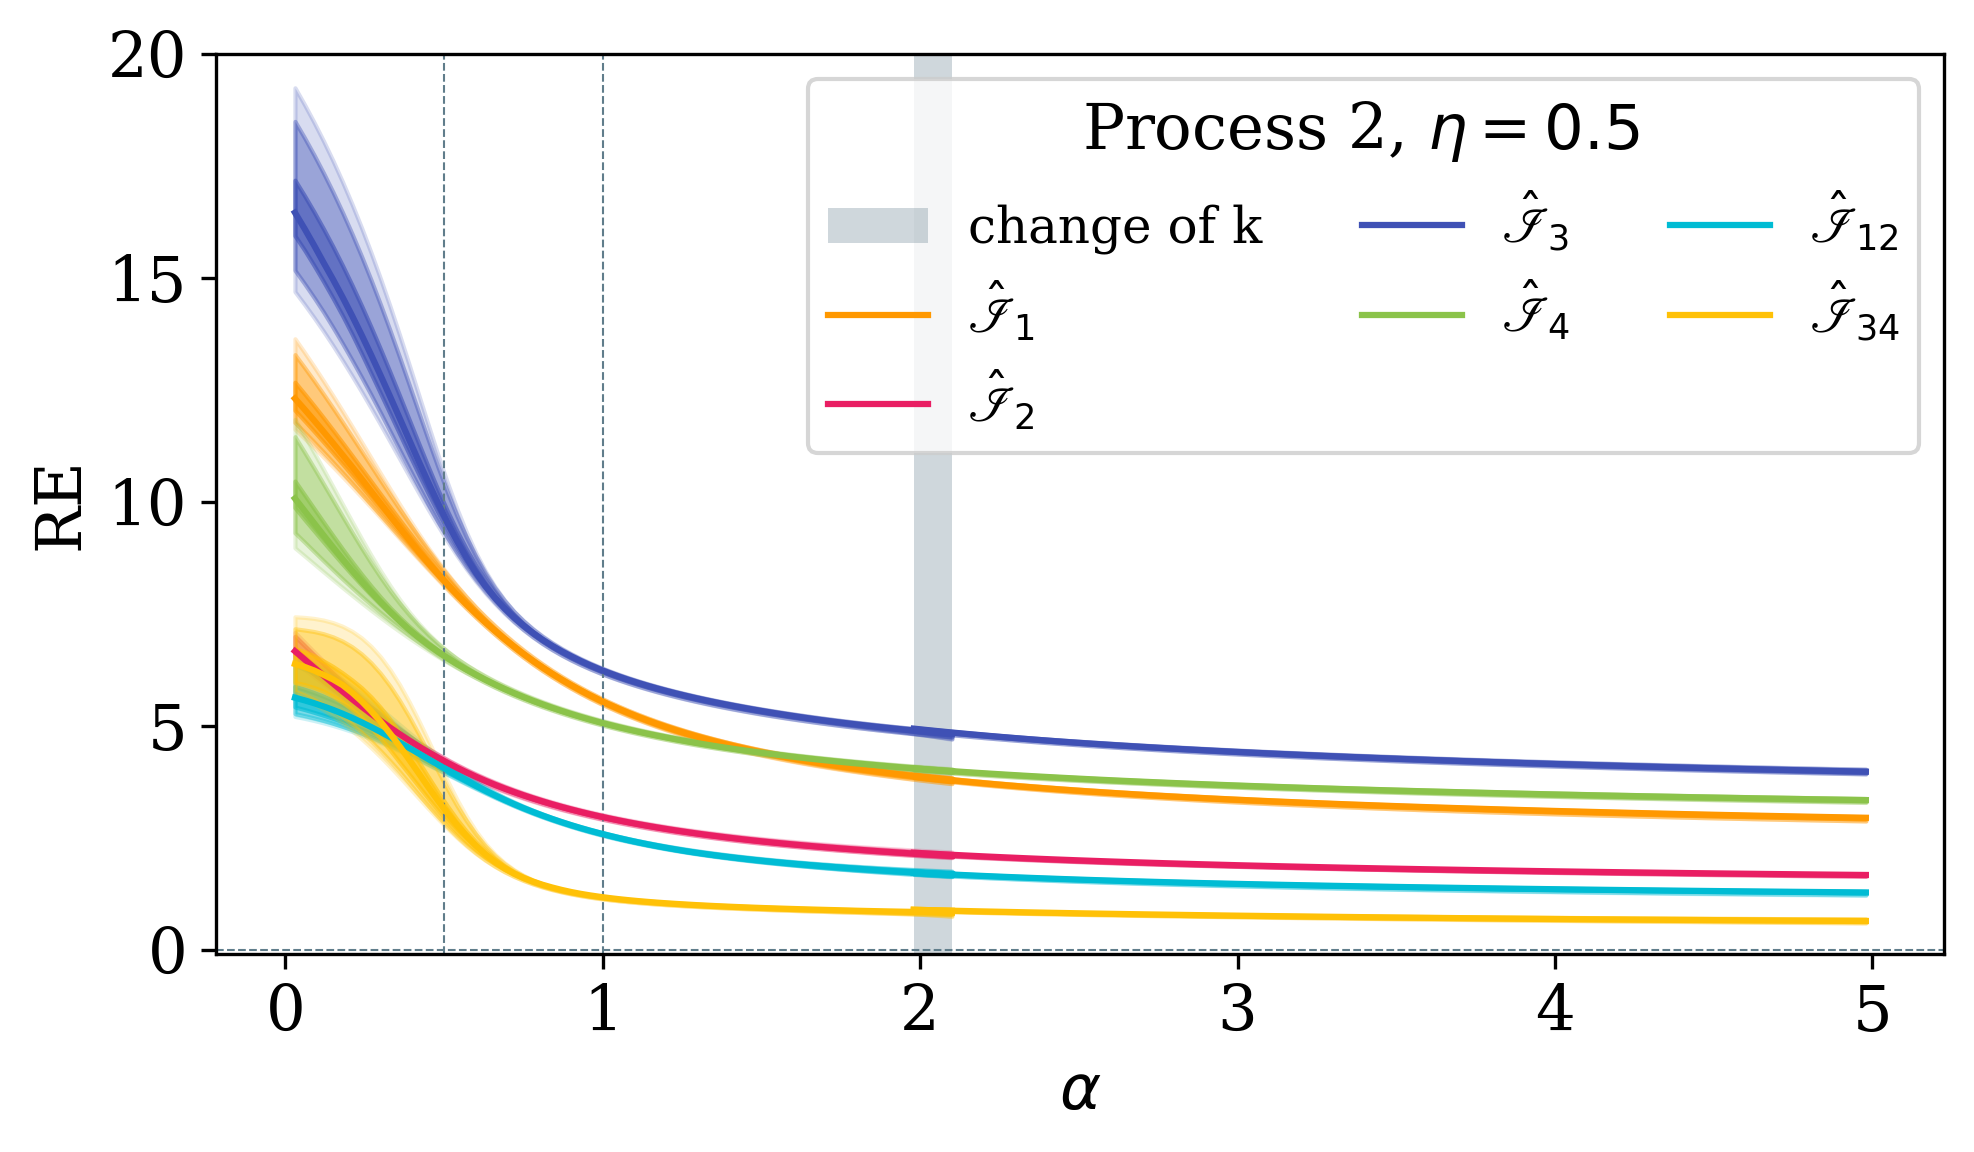

In [136]:

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif', 
    'font.size': 15
})


fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

r=70
l=65


ax.fill_between(alphas[l:r], [-10,-10,-10,-10,-10],[20,20,20,20,20], color=primary_colors[18], alpha=0.3, label=r'change of k', edgecolor='none')


plt.axvline(x=0.5, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axvline(x=1, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axhline(y=0, color=primary_colors[18], linestyle='--', linewidth=0.5)


plot_quantiles(alphas[:r],data=H1_pr2_s[L:2*L,:r,0],color=primary_colors[14],label=r'$\hat{\mathscr{I}}_1$')
plot_quantiles(alphas[:r],data=H2_pr2_s[L:2*L,:r,0],color=primary_colors[1], label=r'$\hat{\mathscr{I}}_2$')
plot_quantiles(alphas[:r],data=H3_pr2_s[L:2*L,:r,0],color=primary_colors[4], label=r'$\hat{\mathscr{I}}_3$')
plot_quantiles(alphas[:r],data=H4_pr2_s[L:2*L,:r,0],color=primary_colors[10], label=r'$\hat{\mathscr{I}}_4$')


plot_quantiles(alphas[:r],data=H12_pr2_s[L:2*L,:r,0],color=primary_colors[7], label=False)
plot_quantiles(alphas[:r],data=H34_pr2_s[L:2*L,:r,0],color=primary_colors[13], label=False)



plot_quantiles(alphas[l:],data=H1_pr2_b[L:2*L,l:,0],color=primary_colors[14], label=False)
plot_quantiles(alphas[l:],data=H2_pr2_b[L:2*L,l:,0],color=primary_colors[1], label=False)
plot_quantiles(alphas[l:],data=H3_pr2_b[L:2*L,l:,0],color=primary_colors[4], label=False)
plot_quantiles(alphas[l:],data=H4_pr2_b[L:2*L,l:,0],color=primary_colors[10], label=False)


plot_quantiles(alphas[l:],data=H12_pr2_b[L:2*L,l:,0],color=primary_colors[7], label=False)
plot_quantiles(alphas[l:],data=H34_pr2_b[L:2*L,l:,0],color=primary_colors[13], label=False)


plot_quantiles(alphas[l:r],data=H12_pr2_b[L:2*L,l:r,0],color=primary_colors[7], label=r'$\hat{\mathscr{I}}_{12}$')
plot_quantiles(alphas[l:r],data=H34_pr2_b[L:2*L,l:r,0],color=primary_colors[13], label=r'$\hat{\mathscr{I}}_{34}$')


ax.set_ylim(-0.1,20)

leg=plt.legend(loc='best', ncol=3, fontsize=12, title=r'Process 2, $\eta=0.5$ ')

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'RE')



# PROCESS 3

In [129]:
L = 10
N = 20000
neigh_num = [3]
a0 = 4*L 
a1 = len(alphas) 
a2 = len(neigh_num) 

H1_pr3_s = np.zeros((a0,a1,a2)) 
H2_pr3_s = np.zeros((a0,a1,a2)) 
H3_pr3_s = np.zeros((a0,a1,a2)) 
H4_pr3_s = np.zeros((a0,a1,a2)) 

H12_pr3_s = np.zeros((a0,a1,a2)) 
H34_pr3_s = np.zeros((a0,a1,a2)) 

H3sh_pr3_s = np.zeros((a0,a1,a2)) 
H4sh_pr3_s = np.zeros((a0,a1,a2)) 

rte_pr3_s = np.zeros((a0,a1,a2)) 
erte_pr3_s = np.zeros((a0,a1,a2)) 


ll = 0


for l in range(0,L):

    A, B, C = ar_lin(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.2,kappa=0.5,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=A,
                                            data_cond=[B],
                                            dimensions=[1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr3_s[ll, :, :] = H1
    H2_pr3_s[ll, :, :] = H2
    H3_pr3_s[ll, :, :] = H3
    H4_pr3_s[ll, :, :] = H4


    H12_pr3_s[ll, :, :] = H1 - H2
    H34_pr3_s[ll, :, :] = H3 - H4


    H3sh_pr3_s[ll, :, :] = H3sh
    H4sh_pr3_s[ll, :, :] = H4sh

    rte_pr3_s[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr3_s[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1


for l in range(0,L):

    A, B, C = ar_lin(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.2,kappa=0.5,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=A,
                                            data_cond=[B,C],
                                            dimensions=[1,1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr3_s[ll, :, :] = H1
    H2_pr3_s[ll, :, :] = H2
    H3_pr3_s[ll, :, :] = H3
    H4_pr3_s[ll, :, :] = H4


    H12_pr3_s[ll, :, :] = H1 - H2
    H34_pr3_s[ll, :, :] = H3 - H4


    H3sh_pr3_s[ll, :, :] = H3sh
    H4sh_pr3_s[ll, :, :] = H4sh

    rte_pr3_s[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr3_s[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1

for l in range(0,L):

    A, B, C = ar_lin(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.2,kappa=0.5,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=C,
                                            data_cond=[B],
                                            dimensions=[1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr3_s[ll, :, :] = H1
    H2_pr3_s[ll, :, :] = H2
    H3_pr3_s[ll, :, :] = H3
    H4_pr3_s[ll, :, :] = H4


    H12_pr3_s[ll, :, :] = H1 - H2
    H34_pr3_s[ll, :, :] = H3 - H4


    H3sh_pr3_s[ll, :, :] = H3sh
    H4sh_pr3_s[ll, :, :] = H4sh

    rte_pr3_s[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr3_s[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1

for l in range(0,L):

    A, B, C = ar_lin(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.2,kappa=0.5,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=C,
                                            data_cond=[B,A],
                                            dimensions=[1,1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr3_s[ll, :, :] = H1
    H2_pr3_s[ll, :, :] = H2
    H3_pr3_s[ll, :, :] = H3
    H4_pr3_s[ll, :, :] = H4


    H12_pr3_s[ll, :, :] = H1 - H2
    H34_pr3_s[ll, :, :] = H3 - H4


    H3sh_pr3_s[ll, :, :] = H3sh
    H4sh_pr3_s[ll, :, :] = H4sh

    rte_pr3_s[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr3_s[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1


All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:33:09 2025
RE 2/6: Mon Dec 29 14:33:09 2025
RE 3/6: Mon Dec 29 14:33:10 2025
RE 4/6: Mon Dec 29 14:33:10 2025
RE shuffle 5/6: Mon Dec 29 14:33:10 2025
RE shuffle 6/6: Mon Dec 29 14:33:11 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:33:11 2025
RE 2/6: Mon Dec 29 14:33:11 2025
RE 3/6: Mon Dec 29 14:33:11 2025
RE 4/6: Mon Dec 29 14:33:12 2025
RE shuffle 5/6: Mon Dec 29 14:33:12 2025
RE shuffle 6/6: Mon Dec 29 14:33:12 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:33:13 2025
RE 2/6: Mon Dec 29 14:33:13 2025
RE 3/6: Mon Dec 29 14:33:13 2025
RE 4/6: Mon Dec 29 14:33:14 2025
RE shuffle 5/6: Mon Dec 29 14:33:14 2025
RE shuffle 6/6: Mon Dec 29 14:33:14 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:33:15 2025
RE 2/6: Mon Dec 29 14:33:15 2025
RE 3/6: Mon Dec 29 14:33:15 2025
RE 4/6: Mon Dec 29 14:33:16 2025
RE shuffle 5/6: Mon Dec 29 14:

In [130]:
L = 10
N = 20000
neigh_num = [50]
a0 = 4*L 
a1 = len(alphas) 
a2 = len(neigh_num) 

H1_pr3_b = np.zeros((a0,a1,a2)) 
H2_pr3_b = np.zeros((a0,a1,a2)) 
H3_pr3_b = np.zeros((a0,a1,a2)) 
H4_pr3_b = np.zeros((a0,a1,a2)) 

H12_pr3_b = np.zeros((a0,a1,a2)) 
H34_pr3_b = np.zeros((a0,a1,a2)) 

H3sh_pr3_b = np.zeros((a0,a1,a2)) 
H4sh_pr3_b = np.zeros((a0,a1,a2)) 

rte_pr3_b = np.zeros((a0,a1,a2)) 
erte_pr3_b = np.zeros((a0,a1,a2)) 


ll = 0


for l in range(0,L):

    A, B, C = ar_lin(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.2,kappa=0.5,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=A,
                                            data_cond=[B],
                                            dimensions=[1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr3_b[ll, :, :] = H1
    H2_pr3_b[ll, :, :] = H2
    H3_pr3_b[ll, :, :] = H3
    H4_pr3_b[ll, :, :] = H4


    H12_pr3_b[ll, :, :] = H1 - H2
    H34_pr3_b[ll, :, :] = H3 - H4


    H3sh_pr3_b[ll, :, :] = H3sh
    H4sh_pr3_b[ll, :, :] = H4sh

    rte_pr3_b[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr3_b[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1


for l in range(0,L):

    A, B, C = ar_lin(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.2,kappa=0.5,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=A,
                                            data_cond=[B,C],
                                            dimensions=[1,1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr3_b[ll, :, :] = H1
    H2_pr3_b[ll, :, :] = H2
    H3_pr3_b[ll, :, :] = H3
    H4_pr3_b[ll, :, :] = H4


    H12_pr3_b[ll, :, :] = H1 - H2
    H34_pr3_b[ll, :, :] = H3 - H4


    H3sh_pr3_b[ll, :, :] = H3sh
    H4sh_pr3_b[ll, :, :] = H4sh

    rte_pr3_b[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr3_b[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1

for l in range(0,L):

    A, B, C = ar_lin(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.2,kappa=0.5,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=C,
                                            data_cond=[B],
                                            dimensions=[1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr3_b[ll, :, :] = H1
    H2_pr3_b[ll, :, :] = H2
    H3_pr3_b[ll, :, :] = H3
    H4_pr3_b[ll, :, :] = H4


    H12_pr3_b[ll, :, :] = H1 - H2
    H34_pr3_b[ll, :, :] = H3 - H4


    H3sh_pr3_b[ll, :, :] = H3sh
    H4sh_pr3_b[ll, :, :] = H4sh

    rte_pr3_b[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr3_b[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1

for l in range(0,L):

    A, B, C = ar_lin(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.2,kappa=0.5,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=C,
                                            data_cond=[B,A],
                                            dimensions=[1,1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr3_b[ll, :, :] = H1
    H2_pr3_b[ll, :, :] = H2
    H3_pr3_b[ll, :, :] = H3
    H4_pr3_b[ll, :, :] = H4


    H12_pr3_b[ll, :, :] = H1 - H2
    H34_pr3_b[ll, :, :] = H3 - H4


    H3sh_pr3_b[ll, :, :] = H3sh
    H4sh_pr3_b[ll, :, :] = H4sh

    rte_pr3_b[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr3_b[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1


All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:34:27 2025
RE 2/6: Mon Dec 29 14:34:27 2025
RE 3/6: Mon Dec 29 14:34:28 2025
RE 4/6: Mon Dec 29 14:34:28 2025
RE shuffle 5/6: Mon Dec 29 14:34:29 2025
RE shuffle 6/6: Mon Dec 29 14:34:29 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:34:29 2025
RE 2/6: Mon Dec 29 14:34:30 2025
RE 3/6: Mon Dec 29 14:34:30 2025
RE 4/6: Mon Dec 29 14:34:30 2025
RE shuffle 5/6: Mon Dec 29 14:34:31 2025
RE shuffle 6/6: Mon Dec 29 14:34:31 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:34:32 2025
RE 2/6: Mon Dec 29 14:34:32 2025
RE 3/6: Mon Dec 29 14:34:32 2025
RE 4/6: Mon Dec 29 14:34:33 2025
RE shuffle 5/6: Mon Dec 29 14:34:33 2025
RE shuffle 6/6: Mon Dec 29 14:34:34 2025
All vectors have the same length equal to: 20000
RE 1/6: Mon Dec 29 14:34:34 2025
RE 2/6: Mon Dec 29 14:34:34 2025
RE 3/6: Mon Dec 29 14:34:35 2025
RE 4/6: Mon Dec 29 14:34:35 2025
RE shuffle 5/6: Mon Dec 29 14:

Text(1.5, 0.17, '$B^{III}_{t+1}=0.2B^{III}_{t}+0.2 A_{t}+ 0.5 D_t + \\epsilon^B_t$')

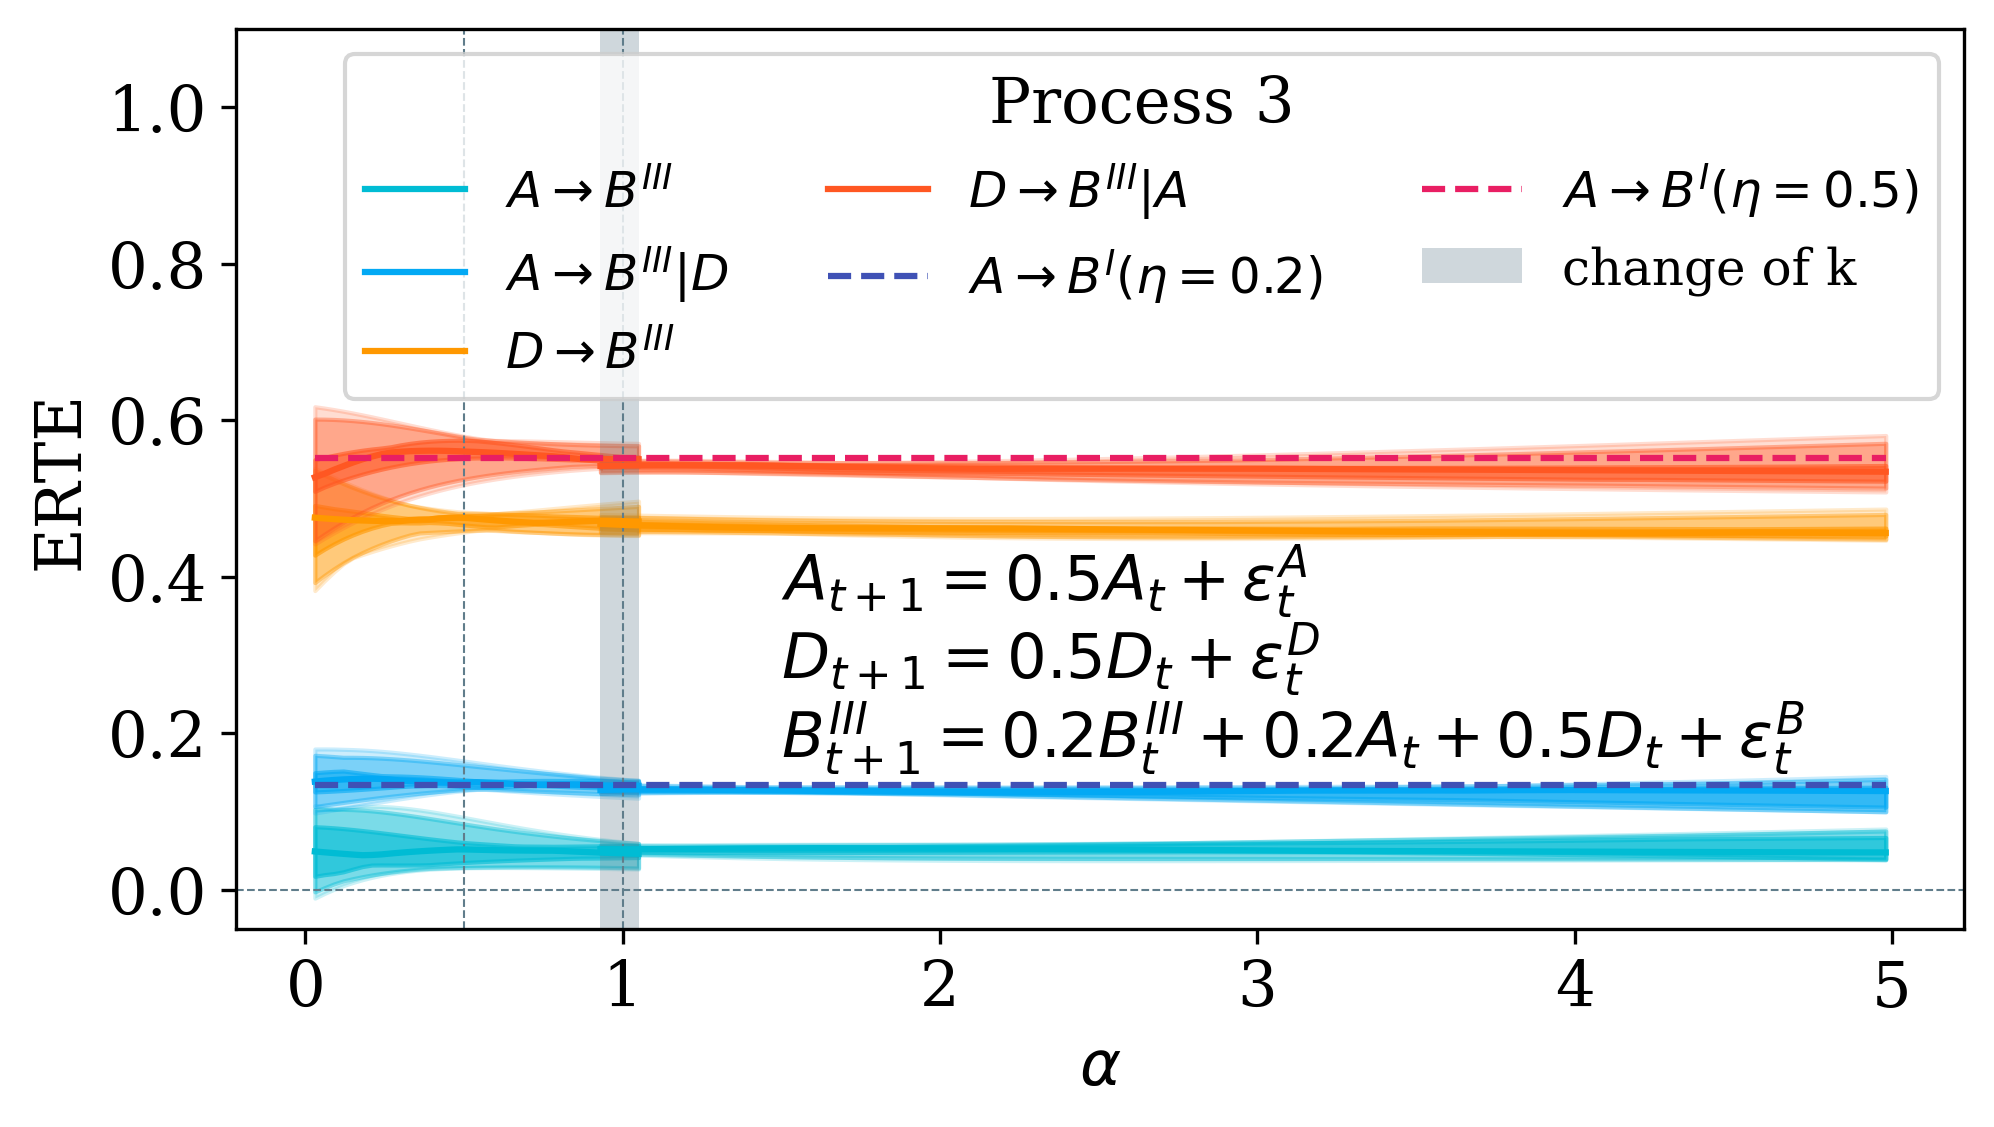

In [137]:

fig = plt.figure(figsize=(7.2, 4.0), dpi=300)
left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

r=35
l=30

plt.axvline(x=0.5, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axvline(x=1, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axhline(y=0, color=primary_colors[18], linestyle='--', linewidth=0.5)



plot_quantiles(alphas[:r],data=erte_pr3_s[:L,:r,0],color=primary_colors[7], label=r'$A \rightarrow B^{III}$')

plot_quantiles(alphas[:r],data=erte_pr3_s[L:2*L,:r,0],color=primary_colors[6], label=r'$A \rightarrow B^{III}|D$')

plot_quantiles(alphas[:r],data=erte_pr3_s[2*L:3*L,:r,0],color=primary_colors[14], label=r'$D \rightarrow B^{III}$')

plot_quantiles(alphas[:r],data=erte_pr3_s[3*L:4*L,:r,0],color=primary_colors[15], label=r'$D \rightarrow B^{III}|A$')


plot_quantiles(alphas[l:],data=erte_pr3_b[:L,l:,0],color=primary_colors[7], label=False)

plot_quantiles(alphas[l:],data=erte_pr3_b[L:2*L,l:,0],color=primary_colors[6], label=False)

plot_quantiles(alphas[l:],data=erte_pr3_b[2*L:3*L,l:,0],color=primary_colors[14], label=False)

plot_quantiles(alphas[l:],data=erte_pr3_b[3*L:4*L,l:,0],color=primary_colors[15], label=False)




ax.plot(alphas,rte_analy[0], linestyle='dashed', color=primary_colors[4], label=r'$A \rightarrow B^{I} (\eta=0.2)$')

ax.plot(alphas,rte_analy[1], linestyle='dashed', color=primary_colors[1], label=r'$A \rightarrow B^{I} (\eta=0.5)$')


ax.set_ylim(-0.05,1.1)

ax.fill_between(alphas[l:r], [-10,-10,-10,-10,-10],[20,20,20,20,20], color=primary_colors[18], alpha=0.3, label=r'change of k', edgecolor='none')

leg=plt.legend(loc='best', ncol=3, fontsize=12, title='Process 3')

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'ERTE')

ax.text(1.5, 0.37, r'$A_{t+1}=0.5A_{t}+ \epsilon^A_t$',  color='k')
ax.text(1.5, 0.27, r'$D_{t+1}=0.5D_{t}+ \epsilon^D_t$',  color='k')

ax.text(1.5, 0.17, r'$B^{III}_{t+1}=0.2B^{III}_{t}+0.2 A_{t}+ 0.5 D_t + \epsilon^B_t$',  color='k')



# PROCESS 4

In [116]:
L = 10
N = 20000
neigh_num = [50]
a0 = 4*L 
a1 = len(alphas) 
a2 = len(neigh_num) 

H1_pr4_b = np.zeros((a0,a1,a2)) 
H2_pr4_b = np.zeros((a0,a1,a2)) 
H3_pr4_b = np.zeros((a0,a1,a2)) 
H4_pr4_b = np.zeros((a0,a1,a2)) 

H12_pr4_b = np.zeros((a0,a1,a2)) 
H34_pr4_b = np.zeros((a0,a1,a2)) 

H3sh_pr4_b = np.zeros((a0,a1,a2)) 
H4sh_pr4_b = np.zeros((a0,a1,a2)) 

rte_pr4_b = np.zeros((a0,a1,a2)) 
erte_pr4_b = np.zeros((a0,a1,a2)) 


ll = 0


for l in range(0,L):

    A, B, C = ar_lin_cube(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.5,kappa=0.2,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=A,
                                            data_cond=[B],
                                            dimensions=[1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr4_b[ll, :, :] = H1
    H2_pr4_b[ll, :, :] = H2
    H3_pr4_b[ll, :, :] = H3
    H4_pr4_b[ll, :, :] = H4


    H12_pr4_b[ll, :, :] = H1 - H2
    H34_pr4_b[ll, :, :] = H3 - H4


    H3sh_pr4_b[ll, :, :] = H3sh
    H4sh_pr4_b[ll, :, :] = H4sh

    rte_pr4_b[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr4_b[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1


for l in range(0,L):

    A, B, C = ar_lin_cube(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.5,kappa=0.2,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=A,
                                            data_cond=[B,C],
                                            dimensions=[1,1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr4_b[ll, :, :] = H1
    H2_pr4_b[ll, :, :] = H2
    H3_pr4_b[ll, :, :] = H3
    H4_pr4_b[ll, :, :] = H4


    H12_pr4_b[ll, :, :] = H1 - H2
    H34_pr4_b[ll, :, :] = H3 - H4


    H3sh_pr4_b[ll, :, :] = H3sh
    H4sh_pr4_b[ll, :, :] = H4sh

    rte_pr4_b[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr4_b[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1

for l in range(0,L):

    A, B, C = ar_lin_cube(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.5,kappa=0.2,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=C,
                                            data_cond=[B],
                                            dimensions=[1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr4_b[ll, :, :] = H1
    H2_pr4_b[ll, :, :] = H2
    H3_pr4_b[ll, :, :] = H3
    H4_pr4_b[ll, :, :] = H4


    H12_pr4_b[ll, :, :] = H1 - H2
    H34_pr4_b[ll, :, :] = H3 - H4


    H3sh_pr4_b[ll, :, :] = H3sh
    H4sh_pr4_b[ll, :, :] = H4sh

    rte_pr4_b[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr4_b[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1

for l in range(0,L):

    A, B, C = ar_lin_cube(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.5,kappa=0.2,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=C,
                                            data_cond=[B,A],
                                            dimensions=[1,1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr4_b[ll, :, :] = H1
    H2_pr4_b[ll, :, :] = H2
    H3_pr4_b[ll, :, :] = H3
    H4_pr4_b[ll, :, :] = H4


    H12_pr4_b[ll, :, :] = H1 - H2
    H34_pr4_b[ll, :, :] = H3 - H4


    H3sh_pr4_b[ll, :, :] = H3sh
    H4sh_pr4_b[ll, :, :] = H4sh

    rte_pr4_b[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr4_b[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1


All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:47:20 2025
RE 2/6: Sat Dec 27 20:47:21 2025
RE 3/6: Sat Dec 27 20:47:21 2025
RE 4/6: Sat Dec 27 20:47:21 2025
RE shuffle 5/6: Sat Dec 27 20:47:22 2025
RE shuffle 6/6: Sat Dec 27 20:47:22 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:47:22 2025
RE 2/6: Sat Dec 27 20:47:23 2025
RE 3/6: Sat Dec 27 20:47:23 2025
RE 4/6: Sat Dec 27 20:47:23 2025
RE shuffle 5/6: Sat Dec 27 20:47:24 2025
RE shuffle 6/6: Sat Dec 27 20:47:24 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:47:25 2025
RE 2/6: Sat Dec 27 20:47:25 2025
RE 3/6: Sat Dec 27 20:47:25 2025
RE 4/6: Sat Dec 27 20:47:26 2025
RE shuffle 5/6: Sat Dec 27 20:47:26 2025
RE shuffle 6/6: Sat Dec 27 20:47:26 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:47:27 2025
RE 2/6: Sat Dec 27 20:47:27 2025
RE 3/6: Sat Dec 27 20:47:27 2025
RE 4/6: Sat Dec 27 20:47:28 2025
RE shuffle 5/6: Sat Dec 27 20:

In [117]:
L = 10
N = 20000
neigh_num = [3]
a0 = 4*L 
a1 = len(alphas) 
a2 = len(neigh_num) 

H1_pr4_s = np.zeros((a0,a1,a2)) 
H2_pr4_s = np.zeros((a0,a1,a2)) 
H3_pr4_s = np.zeros((a0,a1,a2)) 
H4_pr4_s = np.zeros((a0,a1,a2)) 

H12_pr4_s = np.zeros((a0,a1,a2)) 
H34_pr4_s = np.zeros((a0,a1,a2)) 

H3sh_pr4_s = np.zeros((a0,a1,a2)) 
H4sh_pr4_s = np.zeros((a0,a1,a2)) 

rte_pr4_s = np.zeros((a0,a1,a2)) 
erte_pr4_s = np.zeros((a0,a1,a2)) 


ll = 0


for l in range(0,L):

    A, B, C = ar_lin_cube(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.5,kappa=0.2,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=A,
                                            data_cond=[B],
                                            dimensions=[1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr4_s[ll, :, :] = H1
    H2_pr4_s[ll, :, :] = H2
    H3_pr4_s[ll, :, :] = H3
    H4_pr4_s[ll, :, :] = H4


    H12_pr4_s[ll, :, :] = H1 - H2
    H34_pr4_s[ll, :, :] = H3 - H4


    H3sh_pr4_s[ll, :, :] = H3sh
    H4sh_pr4_s[ll, :, :] = H4sh

    rte_pr4_s[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr4_s[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1


for l in range(0,L):

    A, B, C = ar_lin_cube(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.5,kappa=0.2,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=A,
                                            data_cond=[B,C],
                                            dimensions=[1,1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr4_s[ll, :, :] = H1
    H2_pr4_s[ll, :, :] = H2
    H3_pr4_s[ll, :, :] = H3
    H4_pr4_s[ll, :, :] = H4


    H12_pr4_s[ll, :, :] = H1 - H2
    H34_pr4_s[ll, :, :] = H3 - H4


    H3sh_pr4_s[ll, :, :] = H3sh
    H4sh_pr4_s[ll, :, :] = H4sh

    rte_pr4_s[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr4_s[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1

for l in range(0,L):

    A, B, C = ar_lin_cube(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.5,kappa=0.2,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=C,
                                            data_cond=[B],
                                            dimensions=[1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr4_s[ll, :, :] = H1
    H2_pr4_s[ll, :, :] = H2
    H3_pr4_s[ll, :, :] = H3
    H4_pr4_s[ll, :, :] = H4


    H12_pr4_s[ll, :, :] = H1 - H2
    H34_pr4_s[ll, :, :] = H3 - H4


    H3sh_pr4_s[ll, :, :] = H3sh
    H4sh_pr4_s[ll, :, :] = H4sh

    rte_pr4_s[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr4_s[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1

for l in range(0,L):

    A, B, C = ar_lin_cube(alpha=0.5,beta=0.2,ceta=0.5,gamma=0.5,kappa=0.2,n=N,noise=0.5)
    
    H1 , H2 , H3 , H4, H3sh, H4sh = re_sep(data_target=B,
                                            data_source=C,
                                            data_cond=[B,A],
                                            dimensions=[1,1],
                                            par_windows=4,
                                            dim_target=1,
                                            dim_source=1,
                                            dim_future=1,
                                            neigh_num=neigh_num,
                                            alphas=alphas)
   
    H1_pr4_s[ll, :, :] = H1
    H2_pr4_s[ll, :, :] = H2
    H3_pr4_s[ll, :, :] = H3
    H4_pr4_s[ll, :, :] = H4


    H12_pr4_s[ll, :, :] = H1 - H2
    H34_pr4_s[ll, :, :] = H3 - H4


    H3sh_pr4_s[ll, :, :] = H3sh
    H4sh_pr4_s[ll, :, :] = H4sh

    rte_pr4_s[ll, :, :] = (H1 - H2) - (H3 - H4)
    erte_pr4_s[ll, :, :] = ((H1 - H2) - (H3 - H4)) - ((H1 - H2) - (H3sh - H4sh))
        
    ll=ll+1


All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:48:49 2025
RE 2/6: Sat Dec 27 20:48:49 2025
RE 3/6: Sat Dec 27 20:48:49 2025
RE 4/6: Sat Dec 27 20:48:50 2025
RE shuffle 5/6: Sat Dec 27 20:48:50 2025
RE shuffle 6/6: Sat Dec 27 20:48:50 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:48:50 2025
RE 2/6: Sat Dec 27 20:48:51 2025
RE 3/6: Sat Dec 27 20:48:51 2025
RE 4/6: Sat Dec 27 20:48:51 2025
RE shuffle 5/6: Sat Dec 27 20:48:52 2025
RE shuffle 6/6: Sat Dec 27 20:48:52 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:48:52 2025
RE 2/6: Sat Dec 27 20:48:52 2025
RE 3/6: Sat Dec 27 20:48:53 2025
RE 4/6: Sat Dec 27 20:48:53 2025
RE shuffle 5/6: Sat Dec 27 20:48:53 2025
RE shuffle 6/6: Sat Dec 27 20:48:54 2025
All vectors have the same length equal to: 20000
RE 1/6: Sat Dec 27 20:48:54 2025
RE 2/6: Sat Dec 27 20:48:54 2025
RE 3/6: Sat Dec 27 20:48:54 2025
RE 4/6: Sat Dec 27 20:48:55 2025
RE shuffle 5/6: Sat Dec 27 20:

Text(1.9, 0.65, '$B^{IV}_{t+1}=0.2B^{IV}_{t}+0.5 A_{t}+ 0.2 C^3_t + \\epsilon^B_t$')

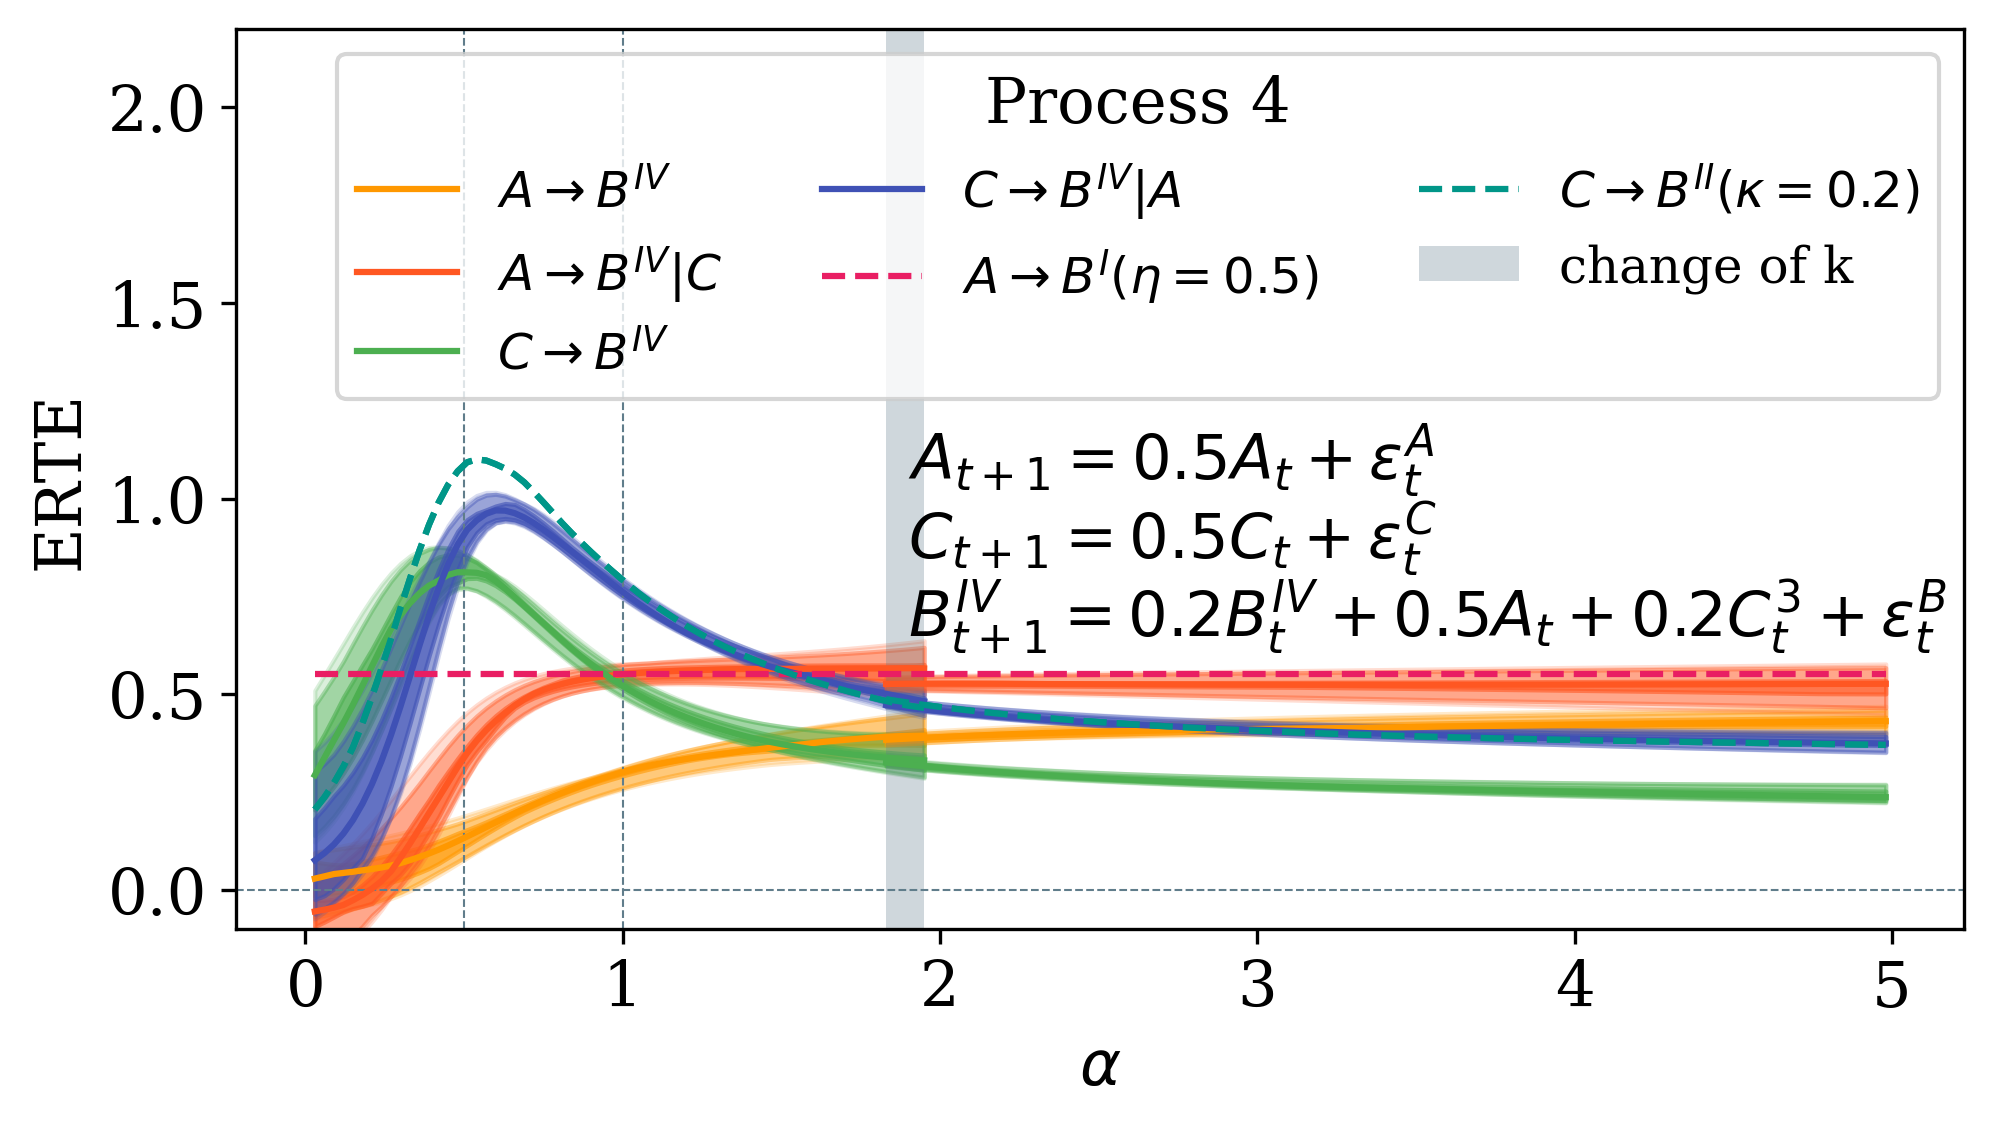

In [138]:


fig = plt.figure(figsize=(7.2, 4.0), dpi=300)
left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

r=65
l=60

plt.axvline(x=0.5, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axvline(x=1, color=primary_colors[18], linestyle='--', linewidth=0.5)
plt.axhline(y=0, color=primary_colors[18], linestyle='--', linewidth=0.5)


quantiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

quantile_values_CB_s = np.quantile(erte_pr2_s[:L,:r], q=quantiles, axis=0)
quantile_values_CB_b = np.quantile(erte_pr2_b[:L,l:], q=quantiles, axis=0)


ax.plot(alphas[:r], quantile_values_CB_s[3], color=primary_colors[8], linestyle='dashed')
ax.plot(alphas[l:], quantile_values_CB_b[3], color=primary_colors[8], linestyle='dashed')


plot_quantiles(alphas[:r],data=erte_pr4_s[:L,:r,0],color=primary_colors[14], label=r'$A \rightarrow B^{IV}$')

plot_quantiles(alphas[:r],data=erte_pr4_s[L:2*L,:r,0],color=primary_colors[15], label=r'$A \rightarrow B^{IV}|C$')

plot_quantiles(alphas[:r],data=erte_pr4_s[2*L:3*L,:r,0],color=primary_colors[9], label=r'$C \rightarrow B^{IV}$')

plot_quantiles(alphas[:r],data=erte_pr4_s[3*L:4*L,:r,0],color=primary_colors[4], label=r'$C \rightarrow B^{IV}|A$')


plot_quantiles(alphas[l:],data=erte_pr4_b[:L,l:,0],color=primary_colors[14], label=False)

plot_quantiles(alphas[l:],data=erte_pr4_b[L:2*L,l:,0],color=primary_colors[15], label=False)

plot_quantiles(alphas[l:],data=erte_pr4_b[2*L:3*L,l:,0],color=primary_colors[9], label=False)

plot_quantiles(alphas[l:],data=erte_pr4_b[3*L:4*L,l:,0],color=primary_colors[4], label=False)





ax.plot(alphas,rte_analy[1], linestyle='dashed', color=primary_colors[1], label=r'$A \rightarrow B^{I} (\eta=0.5)$')
ax.plot(alphas[:r], quantile_values_CB_s[3], color=primary_colors[8],  label=r'$C \rightarrow B^{II} (\kappa=0.2)$', linestyle='dashed')
ax.plot(alphas[l:], quantile_values_CB_b[3], color=primary_colors[8], linestyle='dashed')

ax.set_ylim(-0.1,2.2)



ax.fill_between(alphas[l:r], [-10,-10,-10,-10,-10],[20,20,20,20,20], color=primary_colors[18], alpha=0.3, label=r'change of k', edgecolor='none')


leg=plt.legend(loc='best', ncol=3, fontsize=12, title='Process 4')

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'ERTE')

ax.text(1.9, 1.05, r'$A_{t+1}=0.5A_{t}+ \epsilon^A_t$',  color='k')
ax.text(1.9, 0.85, r'$C_{t+1}=0.5C_{t}+ \epsilon^C_t$',  color='k')
ax.text(1.9, 0.65, r'$B^{IV}_{t+1}=0.2B^{IV}_{t}+0.5 A_{t}+ 0.2 C^3_t + \epsilon^B_t$',  color='k')

